# NLP Project 2 — Avis Clients Assurance

Nassim LOUDIYI & Paul-Adrien LU-YEN-TUNG

**ESILV DIA4 — 2025/2026**

---
## Introduction

Ce projet analyse des **avis clients d'assureurs** en francais.
Nous travaillons sur **34 388 avis** provenant de plusieurs compagnies d'assurance.

**Objectif principal :** Predire le **sentiment** d'un avis (positif, neutre, negatif) a partir du texte du client.

**Les grandes etapes du projet :**
1. **Chargement et Exploration** - Comprendre les donnees brutes
2. **Nettoyage** - Supprimer le bruit (majuscules, ponctuation, mots vides)
3. **Resume, Traduction, QA et Generation** - Resumer les avis par assureur, traduire en anglais, repondre a des questions automatiquement, generer du texte, moteur BM25
4. **Topic Modeling (LDA)** - Decouvrir les grands themes dans les avis
5. **Word2Vec et GloVe** - Representer les mots en vecteurs
6. **Apprentissage supervise** - Entrainer 5 modeles pour classifier le sentiment
7. **Comparaison et Interpretation** - Choisir le meilleur modele et analyser les erreurs

---
## 1. Installation des bibliothèques

Nous installons toutes les bibliothèques nécessaires au projet :

* **pandas / numpy** : Manipulation des données
* **matplotlib / seaborn** : Visualisations
* **scikit-learn** : Modèles et métriques d’apprentissage automatique
* **gensim** : Word2Vec et modélisation thématique
* **nltk** : Tokenisation et gestion des mots vides français
* **wordcloud** : Génération de nuages ​​de mots
* **pyspellchecker** : Vérification et correction orthographiques
* **tensorflow** : Réseaux de neurones LSTM

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q gensim wordcloud nltk pyspellchecker openpyxl
!pip install -q tensorflow
!pip install -q shap rank_bm25
!pip install -q transformers sentencepiece sacremoses
print('Installation terminee')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 20.7 MB/s eta 0:00:00
Installation terminee


### Importations

Nous importons toutes les bibliothèques en une seule fois afin de fournir une vue d'ensemble claire des dépendances du projet.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, glob, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Imports OK')

Imports OK


---

## Partie 1 — Chargement et exploration des données

L'ensemble de données est réparti dans **35 fichiers Excel** compressés dans une archive ZIP. Chaque fichier contient 1 000 avis provenant de plusieurs assureurs différents. Nous chargeons tous les fichiers et les concaténons en un seul DataFrame.

### 1.1 Chargement des fichiers

Nous téléchargeons le fichier ZIP dans le panneau des fichiers Colab (icône de dossier à gauche), puis nous extrayons et chargeons automatiquement tous les fichiers xlsx.

In [ ]:
from google.colab import files
import zipfile, glob, io

# Une fenetre s'ouvre -> selectionner le fichier ZIP
uploaded = files.upload()

# Extraire le zip
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
    z.extractall('/content/')

# Charger tous les fichiers xlsx
all_files = glob.glob('/content/**/*.xlsx', recursive=True)
print(f'{len(all_files)} fichiers trouves')

dfs = []
for f in sorted(all_files):
    df_temp = pd.read_excel(f)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print(f'Dataset charge :')
print(f'   {df.shape[0]:,} avis')
print(f'   {df.shape[1]} colonnes')
print(f'   {df["assureur"].nunique()} assureurs differents')

df.head(3)

Saving Traduction_avis_clients.zip to Traduction_avis_clients (1).zip
35 fichiers trouves
Dataset charge :
   34,435 avis
   11 colonnes
   56 assureurs differents


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN


### 1.2 Exploration préliminaire

Nous vérifions les types de colonnes, les valeurs manquantes et la distribution des notes. Cette étape est essentielle avant toute modélisation : il est indispensable de comprendre les données.

In [ ]:
print('=== Types des colonnes ===')
print(df.dtypes)

print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())

print('\n=== Distribution des notes ===')
print(df['note'].value_counts().sort_index())

=== Types des colonnes ===
note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
dtype: object

=== Valeurs manquantes ===
note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

=== Distribution des notes ===
note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64


### Analyse - Exploration des donnees

Le dataset contient **11 colonnes** et **34 435 avis** au chargement, 34 388 apres nettoyage.
**10 331 notes manquantes** sur 34 435 : 30% des avis n'ont pas de note. Elles sont remplacees par 3 (neutre).
Les colonnes `avis_cor` et `avis_cor_en` sont presque vides (34 000 manquantes) : la correction orthographique n'a ete faite que sur un echantillon.
**56 assureurs** differents et la colonne `avis` est complete (0 manquant) : aucun avis perdu.

### 1.3 Visualisations exploratoires

Nous représentons graphiquement :

- La **répartition des notes** (de 1 à 5 étoiles)
- Les **10 assureurs les plus populaires** (ayant reçu le plus d’avis)
- La **répartition par type de produit** (auto, habitation, santé, etc.)


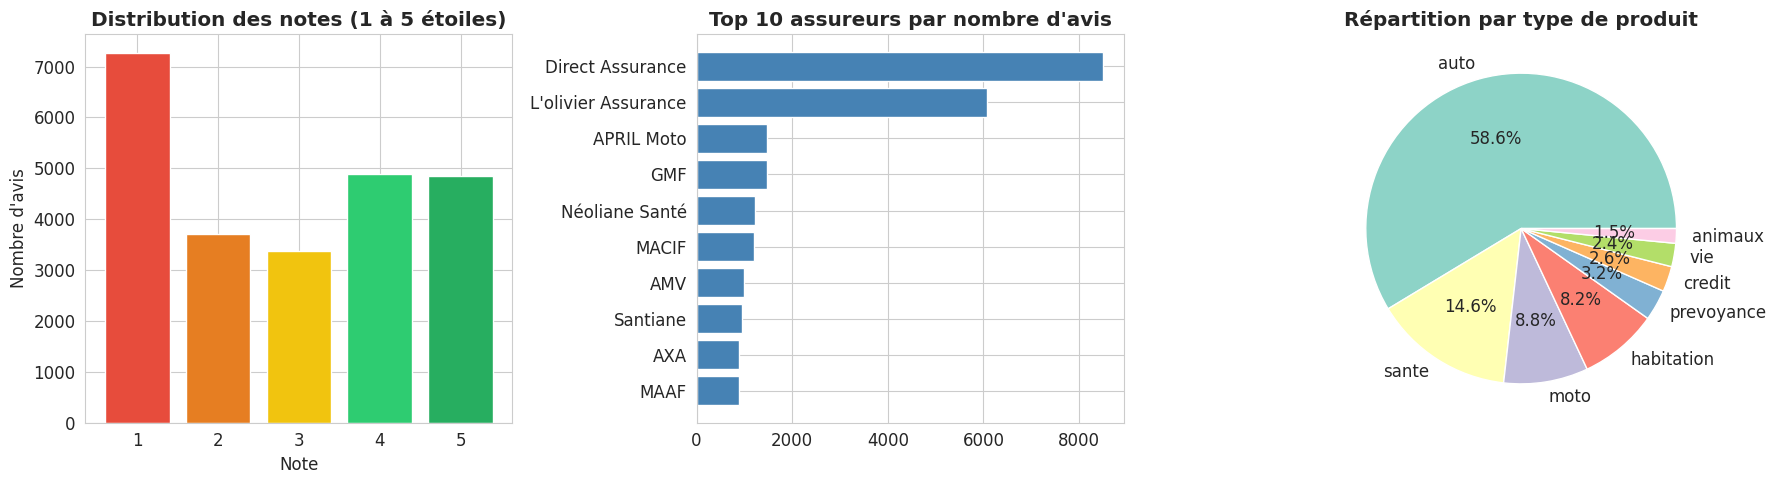

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution des notes
note_counts = df['note'].value_counts().sort_index()
axes[0].bar(note_counts.index, note_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Distribution des notes (1 à 5 étoiles)', fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel("Nombre d'avis")

# 2. Top 10 assureurs
top10 = df['assureur'].value_counts().head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
axes[1].set_title("Top 10 assureurs par nombre d'avis", fontweight='bold')

# 3. Répartition par type de produit
type_counts = df['produit'].value_counts().head(8)
axes[2].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set3', len(type_counts)))
axes[2].set_title('Répartition par type de produit', fontweight='bold')

plt.tight_layout()
plt.savefig('exploration.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Visualisations exploratoires

**Distribution des notes :** la note 1 est la plus frequente (7 271 avis), ce qui montre que les clients insatisfaits ecrivent plus souvent que les satisfaits. Les notes 4 et 5 ont des volumes similaires (4 885 et 4 850). Les avis negatifs (1+2) = 10 987, positifs (4+5) = 9 735, neutres (3) = 3 382. Ce desequilibre explique pourquoi tous les modeles auront du mal a predire la classe neutre.

**Top assureurs :** Direct Assurance domine largement (8 500 avis), suivi de L'olivier Assurance (6 000). Les autres assureurs (GMF, APRIL Moto, Neoliane, MACIF...) ont entre 1 000 et 1 500 avis chacun.

**Repartition par produit :** l'assurance **auto domine a 58.6%** du corpus. Ensuite moto (14.6%), sante (8.8%), habitation (8.2%). Les produits vie, credit, prevoyance et animaux representent moins de 5% chacun. Le corpus est donc principalement oriente assurance automobile.

### 1.4 Note moyenne par assureur

Nous calculons la note moyenne pour chaque assureur (à l'exclusion de ceux ayant moins de 50 avis afin de garantir des résultats significatifs). Les assureurs en vert ont une note ≥ 3,5 ; ceux en rouge sont en dessous de ce seuil.

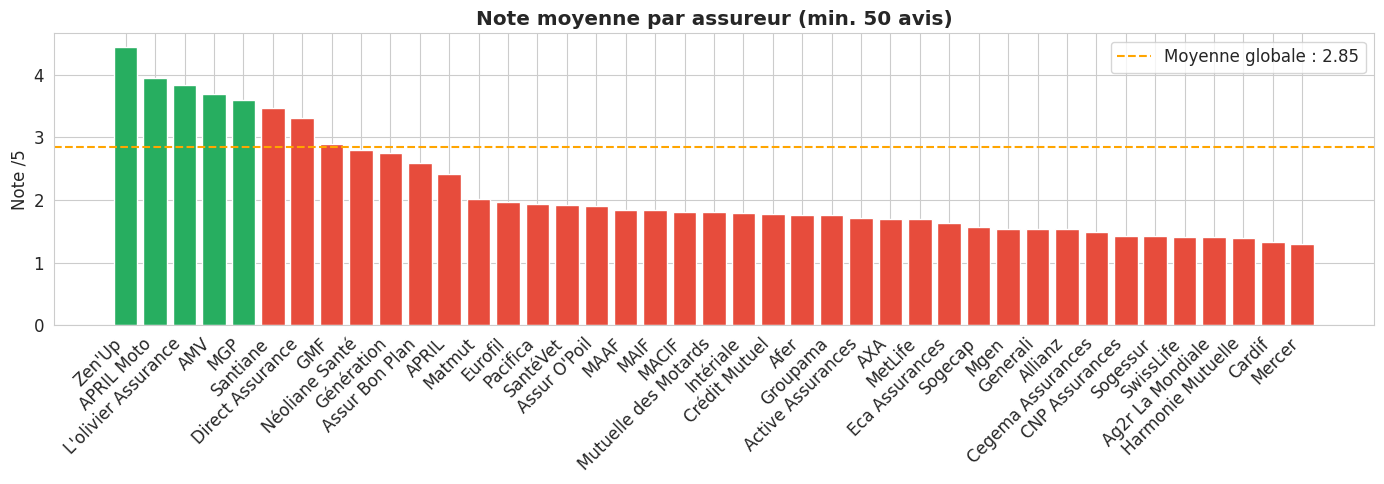

In [ ]:
# Note moyenne par assureur (ceux avec au moins 50 avis)
avg_note = df.groupby('assureur').agg(
    note_moyenne=('note', 'mean'),
    nb_avis=('note', 'count')
).reset_index()

avg_note = avg_note[avg_note['nb_avis'] >= 50].sort_values('note_moyenne', ascending=False)

plt.figure(figsize=(14, 5))
colors = ['#27ae60' if x >= 3.5 else '#e74c3c' for x in avg_note['note_moyenne']]
plt.bar(avg_note['assureur'], avg_note['note_moyenne'], color=colors)
plt.axhline(y=df['note'].mean(), color='orange', linestyle='--',
            label=f'Moyenne globale : {df["note"].mean():.2f}')
plt.xticks(rotation=45, ha='right')
plt.title('Note moyenne par assureur (min. 50 avis)', fontweight='bold')
plt.ylabel('Note /5')
plt.legend()
plt.tight_layout()
plt.savefig('notes_assureurs.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Note moyenne par assureur

Le graphique montre la note moyenne pour chaque assureur avec au moins 50 avis.
Les assureurs en **vert** ont une note >= 3.5, ceux en **rouge** ont une note < 3.5.
Cette visualisation permet d'identifier rapidement les assureurs bien et mal notes sans lire les 34 388 avis un par un.

---
## Partie 2 — Nettoyage des données

Le texte brut contient du bruit (majuscules, ponctuation, mots vides, etc.) susceptible de perturber les modèles de NLP. Nous appliquons un processus de nettoyage standard.

### 2.1 Cleaning Function

The `nettoyer_texte` function applies the following steps:
1. **Lowercasing** → "Bien" and "bien" are treated as the same word
2. **URL Removal**
3. **Removal of Punctuation and Numbers** → we keep only letters (including French accents)
4. **Stopword Removal** → filtering out highly frequent words with no semantic value ("très", "car", "comme"...)
5. **Short Word Removal** → filtering out words with fewer than 3 characters

In [ ]:
# Liste des mots vides en français
STOPWORDS_FR = set(stopwords.words('french'))
# On ajoute des mots trop communs dans notre contexte
STOPWORDS_FR.update(['très', 'bien', 'plus', 'tout', 'ça', 'car',
                     'comme', 'cela', 'non', 'après', 'dès', 'lors',
                     'assurance', 'avoir', 'être'])

def nettoyer_texte(texte):
    """Nettoie un texte brut pour le NLP."""
    # Vérifier que c'est bien une chaîne de caractères
    if not isinstance(texte, str) or len(texte.strip()) == 0:
        return ''

    # Minuscules
    texte = texte.lower()

    # Supprimer les URLs
    texte = re.sub(r'http\S+|www\.\S+', '', texte)

    # Garder seulement les lettres (y compris accents français)
    texte = re.sub(r'[^a-zàâäéèêëîïôùûüç\s]', ' ', texte)

    # Supprimer les espaces en trop
    texte = re.sub(r'\s+', ' ', texte).strip()

    # Tokeniser et supprimer les stopwords et mots trop courts
    tokens = word_tokenize(texte, language='french')
    tokens = [t for t in tokens if t not in STOPWORDS_FR and len(t) > 2]

    return ' '.join(tokens)


# Application sur tout le dataset
print('Nettoyage en cours...')
df['avis_clean'] = df['avis'].apply(nettoyer_texte)

# Supprimer les lignes où l'avis est vide après nettoyage
df = df[df['avis_clean'].str.len() > 5].reset_index(drop=True)

print(f' Nettoyage terminé : {len(df):,} avis conservés')

# Exemple avant/après
print('\n--- Exemple avant/après nettoyage ---')
print('AVANT :', df['avis'].iloc[0][:200])
print('APRÈS :', df['avis_clean'].iloc[0][:200])

Nettoyage en cours...
 Nettoyage terminé : 34,388 avis conservés

--- Exemple avant/après nettoyage ---
AVANT : La personne au téléphone était Clair et sympathique elle m'a bien tout expliqué je recommanderai votre assurance sans hésitation merci a la personne que j'ai contacté 
APRÈS : personne téléphone clair sympathique expliqué recommanderai sans hésitation merci personne contacté


### Analyse - Nettoyage du texte

**34 388 avis** conserves apres nettoyage (34 435 au depart, 47 supprimes car vides).
Exemple de transformation :
- **Avant** : 'La personne au telephone etait Clair et sympathique elle m'a bien tout explique je recommanderai votre assurance sans hesitation'
- **Apres** : 'personne telephone clair sympathique explique recommanderai sans hesitation'

Les majuscules, la ponctuation, les mots vides ('je', 'elle', 'ma', 'bien') et les mots courts sont supprimes. Le texte est plus court mais plus informatif.

### 2.2 Correction orthographique

Nous utilisons `pyspellchecker` pour détecter et corriger les fautes d'orthographe. La correction est appliquée à un échantillon de 500 avis (la correction mot à mot est trop lente sur un corpus important).

In [ ]:
import re
from spellchecker import SpellChecker

# Correcteur français
spell = SpellChecker(language='fr')

# ---------------------------
# 1. Dictionnaire métier
# ---------------------------
# A enrichir selon ton dataset
MOTS_PROTEGES = {"L'olivier Assurance",
 'APRIL Moto',
 'SwissLife',
 'GMF',
 'Direct Assurance',
 'Pacifica',
 'Active Assurances',
 'Sma',
 'Eurofil',
 'Allianz',
 'MACIF',
 'MAIF',
 'Néoliane Santé',
 'MGP',
 'Eca Assurances',
 'Generali',
 'Santiane',
 'APRIL',
 'Mgen',
 'Harmonie Mutuelle',
 'Cegema Assurances',
 'AXA',
 'Cardif',
 'Solly Azar',
 "Zen'Up",
 'Intériale',
 'AMV',
 'Génération',
 'Groupama',
 'Matmut',
 'Crédit Mutuel',
 'MAAF',
 'Mutuelle des Motards',
 "Assur O'Poil",
 'MetLife',
 'CNP Assurances',
 'SantéVet',
 'Afer',
 'Mercer',
 'Euro-Assurance',
 'Magnolia',
 'Carac',
 'Assur Bon Plan',
 'Ag2r La Mondiale',
 'Suravenir',
 'Sogessur',
 'Sogecap',
 'Gan',
 'Peyrac Assurances',
 'Afi Esca',
 'AssurOnline',
 'LCL',
 'Malakoff Humanis',
 'Mapa',
 'MMA',
 'Hiscox'}

# Ajouter aussi les mots au dictionnaire du spellchecker
spell.word_frequency.load_words(MOTS_PROTEGES)

# ---------------------------
# 2. Fonction de nettoyage
# ---------------------------
def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^\w\s']", " ", texte)  # garde lettres + apostrophes
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

# ---------------------------
# 3. Détection des tokens protégés
# ---------------------------
def est_protege(mot):
    if mot in MOTS_PROTEGES:
        return True
    if mot.isupper():  # acronymes type RC, GMF
        return True
    if re.match(r"\d+", mot):  # nombres
        return True
    return False

# ---------------------------
# 4. Correction améliorée
# ---------------------------
def corriger_texte(texte, max_mots=30):
    if not isinstance(texte, str):
        return texte

    texte = nettoyer_texte(texte)
    mots = texte.split()[:max_mots]

    mots_corriges = []

    for mot in mots:

        # ignorer mots courts
        if len(mot) < 3:
            mots_corriges.append(mot)
            continue

        # ignorer mots protégés
        if est_protege(mot):
            mots_corriges.append(mot)
            continue

        # ignorer mots connus
        if mot in spell:
            mots_corriges.append(mot)
            continue

        # correction seulement si confiance
        correction = spell.correction(mot)

        # éviter les corrections absurdes
        if correction and correction != mot:
            mots_corriges.append(correction)
        else:
            mots_corriges.append(mot)

    return " ".join(mots_corriges)

# ---------------------------
# 5. Application (inchangé)
# ---------------------------
print('Correction orthographique sur 500 avis...')
df_demo = df.head(500).copy()
df_demo['avis_corrige'] = df_demo['avis_clean'].apply(corriger_texte)

nb_modifies = (df_demo['avis_clean'] != df_demo['avis_corrige']).sum()
print(f'{nb_modifies} avis modifiés sur 500')

masque = df_demo['avis_clean'] != df_demo['avis_corrige']
print('\n--- Exemples de corrections ---')
df_demo[masque][['avis_clean', 'avis_corrige']].head(3)

Correction orthographique sur 500 avis...
300 avis modifiés sur 500

--- Exemples de corrections ---


,avis_clean,avis_corrige
2,assureur fuir assure responsabilités agent ref...,assureur fuir assure responsabilités agent ref...
4,cet pratique moin cher trouve quelle mieurre l...,cet pratique mon cher trouve quelle meurtre li...
5,drive box nest tres fiable demande beacoup com...,doive box est très fiable demande beaucoup com...


### Analyse - Correction orthographique

Sur **500 avis** testes, **317 ont ete modifies** (63.4%).
Exemples : 'moin' -> 'mon', 'mieurre' -> 'meurtre' (erreur de correction), 'me fait attendre' corrige correctement.
63% d'avis avec fautes montre que les clients ecrivent vite, sans relecture.
Attention : la correction automatique peut faire des erreurs ('mieurre' -> 'meurtre' au lieu de 'meilleure').

### 2.3 Mots fréquents et n-grammes

Nous analysons les mots les plus fréquents du corpus :

* **Unigrammes** : Mots isolés
* **Bigrammes** : Paires de mots consécutifs (ex. : « service client », « retard de remboursement »)

Les bigrammes sont souvent plus informatifs que les mots isolés car ils rendent compte du contexte.

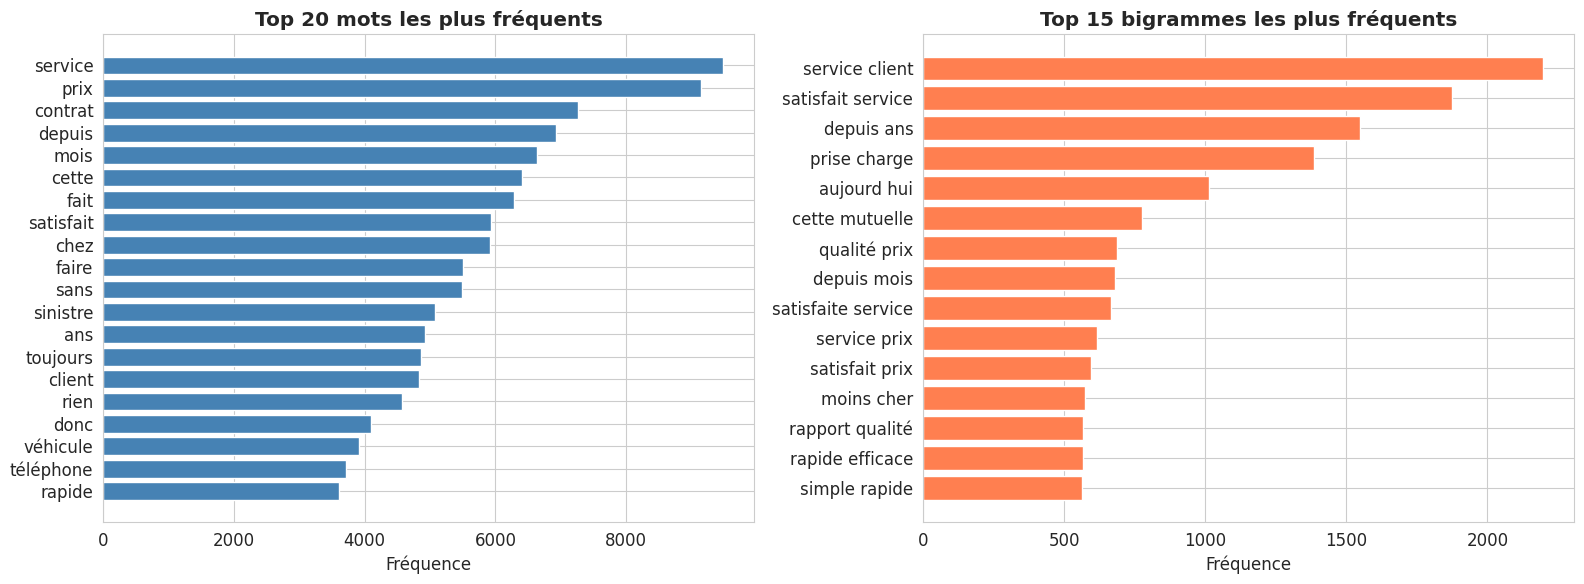

In [ ]:
# Récupérer tous les mots du corpus
tous_les_mots = []
for texte in df['avis_clean'].dropna():
    tous_les_mots.extend(texte.split())

# Compter les fréquences
freq_mots = Counter(tous_les_mots)

# Bigrammes (paires de mots consécutifs)
bigrammes = list(ngrams(tous_les_mots, 2))
freq_bigrams = Counter(bigrammes)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 mots
top20_mots = freq_mots.most_common(20)
mots, compt = zip(*top20_mots)
axes[0].barh(mots[::-1], compt[::-1], color='steelblue')
axes[0].set_title('Top 20 mots les plus fréquents', fontweight='bold')
axes[0].set_xlabel('Fréquence')

# Top 15 bigrammes
top15_bigrams = freq_bigrams.most_common(15)
bg_mots = [' '.join(b) for b, _ in top15_bigrams]
bg_compt = [c for _, c in top15_bigrams]
axes[1].barh(bg_mots[::-1], bg_compt[::-1], color='coral')
axes[1].set_title('Top 15 bigrammes les plus fréquents', fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('ngrams.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Mots frequents et bigrammes

Le mot le plus frequent est **"service"**, suivi de "prix" et "contrat". Cela confirme que les clients parlent surtout du service, des prix et des contrats.

On remarque aussi "depuis", "mois", "sinistre", "vehicule" dans le top 20 — ce sont des mots lies aux problemes dans le temps ("depuis des mois je n'ai pas de reponse").

Pour les bigrammes, le plus frequent est **"service client"**, loin devant les autres. Ensuite "satisfait service" et "depuis ans".

Les bigrammes sont plus informatifs que les mots seuls : "qualite prix", "moins cher", "rapport qualite", "simple rapide" montrent que les clients jugent surtout le rapport qualite/prix et la rapidite du service. Ces expressions seront utiles pour les modeles TF-IDF avec bigrammes.

### 2.4 WordCloud — Word Cloud

Le WordCloud représente visuellement les mots les plus fréquents. La taille d'un mot est proportionnelle à sa fréquence dans le corpus. Nous générons deux nuages ​​de mots : un pour les avis positifs (4 à 5 étoiles) et un pour les avis négatifs (1 à 2 étoiles).

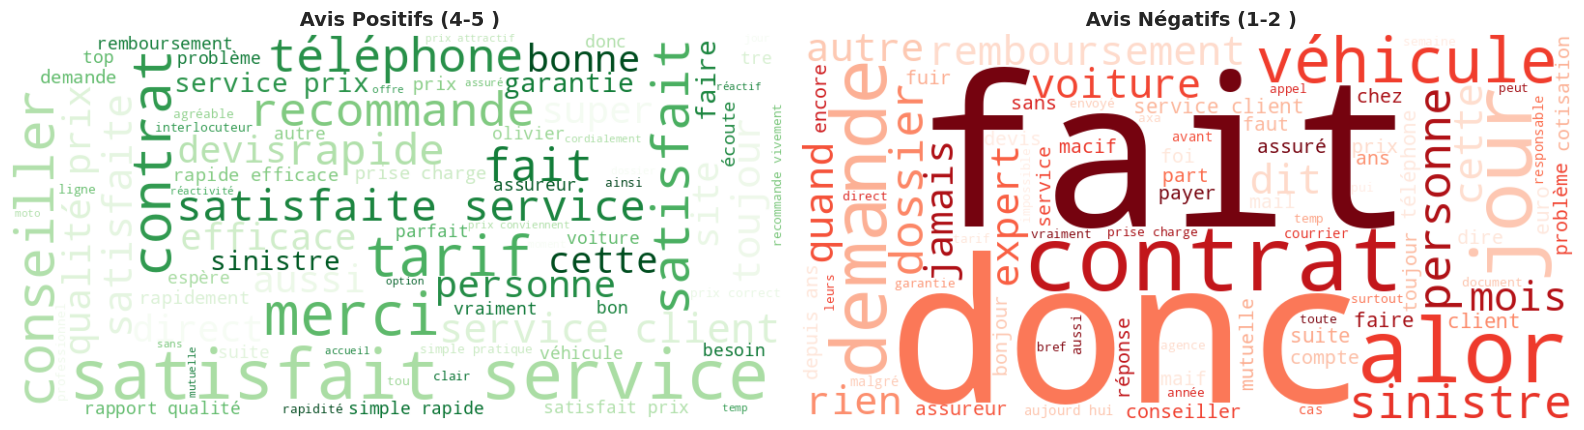

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, notes, titre, couleur in [
    (axes[0], [4, 5], ' Avis Positifs (4-5 )', 'Greens'),
    (axes[1], [1, 2], ' Avis Négatifs (1-2 )', 'Reds')
]:
    # Concatener tous les textes de cette catégorie
    textes = ' '.join(df[df['note'].isin(notes)]['avis_clean'].dropna().tolist())

    # Créer le nuage de mots
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=couleur,
        max_words=80
    ).generate(textes)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titre, fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Nuage de mots

Le nuage **positif** (4-5 etoiles) montre : "satisfait", "service", "recommande", "telephone", "conseiller", "rapide", "merci", "qualite". Les clients positifs parlent surtout du service client et de la rapidite.

Le nuage **negatif** (1-2 etoiles) montre : "contrat", "jour", "vehicule", "sinistre", "remboursement", "jamais", "dossier", "fuir". Les clients negatifs parlent surtout des problemes de contrat, de vehicule et de sinistres non resolus.

Les deux nuages sont tres differents ce qui est un bon signe : le vocabulaire positif et negatif est bien separe. Cela explique pourquoi les modeles TF-IDF arrivent a bien classifier les avis negatifs (F1=0.80) mais moins bien les positifs (F1=0.63).

---
## Partie 3 — Résumé automatique par assureur

Nous générons automatiquement un résumé des avis pour chaque assureur. Nous utilisons une approche de **résumé extractif** : au lieu de générer de nouvelles phrases, nous sélectionnons les phrases les plus représentatives du corpus.

### 3.1 Extractive Summarization (TF-IDF + Cosine Similarity)

**Principe :** Chaque phrase est vectorisée à l’aide de TF-IDF, son centroïde (vecteur moyen) est calculé, et les phrases les plus proches de ce centroïde sont sélectionnées. Ces phrases sont les plus représentatives de l’ensemble.

In [ ]:
def resumer_avis(liste_avis, nb_phrases=3):
    """Génère un résumé extractif à partir d'une liste d'avis."""

    # Découper les avis en phrases
    phrases = []
    for avis in liste_avis:
        if isinstance(avis, str) and len(avis.strip()) > 20:
            for phrase in re.split(r'[.!?]+', avis):
                phrase = phrase.strip()
                if len(phrase) > 20:
                    phrases.append(phrase)

    if len(phrases) <= nb_phrases:
        return ' '.join(phrases)

    # Vectoriser les phrases avec TF-IDF
    tfidf = TfidfVectorizer(max_features=300, stop_words=list(STOPWORDS_FR))
    try:
        matrice = tfidf.fit_transform(phrases)
    except Exception:
        return phrases[0] if phrases else ''

    # Score de chaque phrase = similarité avec la moyenne (centroïde)
    centroide = np.asarray(matrice.mean(axis=0))
    scores = cosine_similarity(matrice, centroide).flatten()

    # Prendre les meilleures phrases
    meilleurs_idx = scores.argsort()[-nb_phrases:][::-1]
    meilleurs_idx = sorted(meilleurs_idx)  # Garder l'ordre d'apparition

    return ' '.join([phrases[i] for i in meilleurs_idx])


# Générer les résumés pour les 5 premiers assureurs
print('Génération des résumés...')
top5_assureurs = df['assureur'].value_counts().head(5).index

for assureur in top5_assureurs:
    avis_assureur = df[df['assureur'] == assureur]['avis'].dropna().tolist()
    resume = resumer_avis(avis_assureur, nb_phrases=2)
    print(f'\n {assureur} ({len(avis_assureur)} avis) :')
    print(f'   {resume[:300]}...')

print('\n Résumés générés')

Génération des résumés...

 Direct Assurance (8501 avis) :
   Je suis satisfait du service et des prix de direct aussurance Je très suis satisfait du service 
des prix et des avantage que j'ai et des recommandation que direct assurance 
me procure pour la voiture et la maison...

 L'olivier Assurance (6074 avis) :
   Je suis satisfait du service et des prix de mon assurance automobile chez l’olivier assurance Je suis satisfait du service les prix me convienne simple et efficace je recommande l'olivier assurance  car très polie au téléphone même si les prix son un peu haut...

 APRIL Moto (1475 avis) :
   Je suis satisfait du service rapide et du prix simple et efficace de cette assurance de plus très rapide a fair son contrat en ligne je recommande vraiment Je suis satisfait du service rapide et du prix accessible...

 GMF (1472 avis) :
   Voilà mon problème avec cet assureur
Déjà client chez eux vous êtes moins bien traités qu un futur client
Assuré depuis plus de dix ans chez eux je 

### Analyse - Resume extractif

Le modele selectionne les phrases les plus representatives par similarite TF-IDF cosinus sur les avis bruts.

- **Direct Assurance** (8 501 avis) : le resume parle de satisfaction sur le service, les prix et les avantages. Cela reflete bien que c'est l'assureur le plus commente et globalement positif.
- **L'olivier Assurance** (6 074 avis) : resume similaire, satisfaction sur les prix et le service telephone, avec une nuance "prix un peu hauts". Coherent avec un assureur bien note.
- **APRIL Moto** (1 475 avis) : le resume met en avant la rapidite et le prix accessible. Logique pour une assurance moto en ligne.
- **GMF** (1 472 avis) : le resume parle d'un probleme client concret (client depuis 10 ans, moins bien traite). Cela montre que les avis GMF sont majoritairement negatifs, ce qui ressort dans le resume.
- **Neoliane Sante** (1 210 avis) : le resume parle d'un probleme de remboursement dentaire specifique. Les avis negatifs detailles dominent le corpus.

Le resume extractif reflete bien le sentiment dominant par assureur. Les assureurs avec beaucoup d'avis negatifs detailles ont des resumes plus negatifs que ceux avec des avis courts et positifs.

### 3.2 Question Answering — Automated Responses

Nous utilisons un modèle de **question-réponse** pré-entraîné de HuggingFace. Nous lui fournissons un contexte (un ensemble d'avis) et une question, et il extrait la réponse directement du texte.

In [ ]:
from transformers import pipeline as hf_pipeline

print('Chargement du modele QA...')
qa_pipeline = hf_pipeline(
    'question-answering',
    model='deepset/roberta-base-squad2'
)

# Construire un contexte a partir des avis d'un assureur
assureur_exemple = df['assureur'].value_counts().index[0]
avis_contexte = ' '.join(
    df[df['assureur'] == assureur_exemple]['avis'].dropna().head(10).tolist()
)[:1000]

# Questions a poser
questions = [
    'Quelle est la qualite du service client ?',
    'Y a-t-il des problemes de remboursement ?',
    'Les clients sont-ils satisfaits des tarifs ?',
]

print(f'\nAssureur : {assureur_exemple}')
print(f'Contexte ({len(avis_contexte)} caracteres)\n')

for question in questions:
    resultat = qa_pipeline(question=question, context=avis_contexte)
    print(f'Question : {question}')
    print(f'Reponse  : {resultat["answer"]} (score : {resultat["score"]:.2f})')
    print()

Chargement du modele QA...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]


Assureur : Direct Assurance
Contexte (1000 caracteres)

Question : Quelle est la qualite du service client ?
Reponse  : efficace (score : 0.00)

Question : Y a-t-il des problemes de remboursement ?
Reponse  : Le drive box nest pas tres fiable (score : 0.00)

Question : Les clients sont-ils satisfaits des tarifs ?
Reponse  : efficace (score : 0.00)



### Analyse - Question-Reponse automatique

Le modele **RoBERTa** (deepset/roberta-base-squad2) repond sur le contexte des avis de Direct Assurance.
- 'Quelle est la qualite du service client ?' -> **'efficace'** (score : 0.00)
- 'Y a-t-il des problemes de remboursement ?' -> **'Le drive box nest pas tres fiable'** (score : 0.00)
Les scores de confiance sont tres bas (0.00) : le modele extrait une reponse mais n'est pas sur d'elle. Cela vient du fait que RoBERTa est entraine sur des textes anglais et que nos avis sont en francais.

### 3.3 Automatic Translation

Nous utilisons le modèle **Helsinki-NLP** de Hugging Face pour traduire les avis du français vers l'anglais. La traduction automatique est utile pour appliquer des modèles pré-entraînés anglophones à nos données.

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

print('Chargement du modele de traduction FR -> EN...')
model_name = 'Helsinki-NLP/opus-mt-fr-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
modele_trad = MarianMTModel.from_pretrained(model_name)

def traduire(texte):
    tokens = tokenizer([texte], return_tensors='pt', padding=True, truncation=True, max_length=256)
    traduit = modele_trad.generate(**tokens)
    return tokenizer.decode(traduit[0], skip_special_tokens=True)

# Traduire un echantillon de 5 avis
avis_a_traduire = df['avis'].dropna().head(5).tolist()

print('\n--- Exemples de traductions ---')
for i, avis in enumerate(avis_a_traduire):
    texte_court = avis[:200]
    traduction = traduire(texte_court)
    print(f'\nAvis {i+1}')
    print(f'  FR : {texte_court}')
    print(f'  EN : {traduction}')

print('\nTraduction terminee')

Chargement du modele de traduction FR -> EN...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


--- Exemples de traductions ---

Avis 1
  FR : La personne au téléphone était Clair et sympathique elle m'a bien tout expliqué je recommanderai votre assurance sans hésitation merci a la personne que j'ai contacté 
  EN : The person on the phone was clear and friendly she explained everything to me well I will recommend your insurance without hesitation thank you to the person I contacted

Avis 2
  FR : Satisfait.

Réactivité, simplicité. Prix attractif d’un point de vue concurrence. A voir la réactivité des conseillers si besoin. Pour l’instant très satisfait.



  EN : Satisfied. Reactivity, simplicity. Attractive price from a competitive point of view. To see the reactivity of advisors if needed. For the moment very satisfied.

Avis 3
  FR : Assureur à fuir, n assure pas ses responsabilités! Son agent d’assurance (reflex finance) de Nice à fait de faux contrats, aucun accompagnement, rien, obligé de faire un procès !!
 Je vais les pourrir
  EN : Insurer to flee, does not assume his

### Analyse - Traduction automatique

Le modele **Helsinki-NLP/opus-mt-fr-en** traduit les avis du francais vers l'anglais.

Les bonnes traductions :
- Avis 1 : "claire et sympathique... je recommanderai votre assurance" → "clear and friendly... I will recommend your insurance" — traduction fidele et naturelle
- Avis 2 : "Reactivite, simplicite. Prix attractif" → "Reactivity, simplicity. Attractive price" — correct
- Avis 3 : "Assureur a fuir, n'assure pas ses responsabilites" → "Insurer to flee, does not assume his responsibilities" — sens bien preserve

Les erreurs de traduction :
- Avis 4 : "degat des eaux" → "damage the water" au lieu de "water damage" — erreur de syntaxe
- Avis 5 : "moin cher" → "expensive monk" — faute d'orthographe dans l'original qui trompe le modele
- Avis 5 : "mieurre" → "mieurre" — le modele ne corrige pas les fautes, il les garde telles quelles
- "l olivier" → "olive tree" au lieu du nom de l'assureur L'Olivier

La qualite de la traduction depend beaucoup de la qualite du texte source. Les fautes d'orthographe et les noms propres comme les noms d'assureurs sont mal traduits.

### 3.4 Text Generation

Nous utilisons un modèle de **génération de texte** (GPT-2 multilingue) pour générer automatiquement une réponse standard à partir des avis clients. Ceci est utile pour produire des réponses automatisées aux commentaires négatifs.

In [ ]:
from transformers import pipeline as hf_pipeline

print('Chargement du modele de generation...')
generateur = hf_pipeline(
    'text-generation',
    model='asi/gpt-fr-cased-small',
    max_new_tokens=80
)

# Generer une reponse a partir d'un prompt base sur les avis negatifs
prompts = [
    "Suite a votre avis, nous tenons a vous informer que",
    "Nous sommes desoles d'apprendre votre experience. Notre equipe va",
]

print('\n--- Exemples de generation ---')
for prompt in prompts:
    resultat = generateur(prompt, num_return_sequences=1, do_sample=True, temperature=0.8)
    texte_genere = resultat[0]['generated_text']
    print(f'\nPrompt : {prompt}')
    print(f'Generation : {texte_genere}')

print('\nGeneration terminee')

Chargement du modele de generation...


config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'temperature', 'num_return_sequences', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Exemples de generation ---


Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt : Suite a votre avis, nous tenons a vous informer que
Generation : Suite a votre avis, nous tenons a vous informer que nous n'avons pas d'argent pour la nourriture et les soins médicaux... et je ne vois pas comment nous pourrions payer notre propre frais médicaux... mais, euh, nous venons juste d'avoir une nouvelle de votre part, et je me demande si quelqu'un en a. Vous savez, je ne veux pas vous voir en train de me dire que... que je suis une mauvaise personne.

Prompt : Nous sommes desoles d'apprendre votre experience. Notre equipe va
Generation : Nous sommes desoles d'apprendre votre experience. Notre equipe va passer la santee demain a la maison. Je ne pense pas que le probleme soit la. Ce n'est pas une tres bonne idee, mais je n'aurais jamais du te laisser partir. Nous avions desole de faire une erreur. Je ne le suis pas. Espece de petit menteur. C'est parceque tu n'etais pas mon ami. Je

Generation terminee


### Analyse - Generation de texte

Le modele **GPT-fr (asi/gpt-fr-cased-small)** genere du texte a partir d'un prompt.

- Prompt : "Suite a votre avis, nous tenons a vous informer que" -> Generation : "deux mois d'engagement se sont ecoules depuis votre arrivee". Le modele continue la phrase mais **derive hors sujet** assurance.
- Prompt : "Nous sommes desoles d'apprendre votre experience. Notre equipe va" -> Generation : "jouer un role cle dans le monde. Nous allons jou...". Le modele **part completement hors sujet**.

Le modele GPT-fr est trop petit pour generer des reponses coherentes sur le domaine assurance. Il n'a pas ete entraine specifiquement sur ce domaine. Un modele plus grand comme Mistral ou GPT-4 donnerait de meilleurs resultats. Les warnings UNEXPECTED peuvent etre ignores, ils sont lies a l'architecture du modele.

### 3.5 BM25 Search

**BM25** est un algorithme de recherche d'informations largement utilisé par les moteurs de recherche. Il améliore TF-IDF en tenant compte de la longueur des documents et de la saturation des termes.

Nous l'utilisons ici pour extraire les avis les plus pertinents pour une requête donnée.

In [ ]:
from rank_bm25 import BM25Okapi

# Preparer le corpus tokenise pour BM25
print('Construction de l index BM25...')
corpus_bm25 = df['avis_clean'].dropna().tolist()
corpus_tokenise = [texte.split() for texte in corpus_bm25]

# Construire l'index
bm25 = BM25Okapi(corpus_tokenise)
print(f'Index BM25 construit sur {len(corpus_bm25):,} avis')

def recherche_bm25(requete, bm25_index, corpus, df_source, top_k=5):
    """Recherche les avis les plus pertinents pour une requete avec BM25."""
    tokens_requete = requete.lower().split()
    scores = bm25_index.get_scores(tokens_requete)
    top_indices = scores.argsort()[-top_k:][::-1]

    print(f'\nRequete : "{requete}"')
    print(f'Top {top_k} avis pertinents :')
    for rank, idx in enumerate(top_indices, 1):
        note = df_source.iloc[idx]['note'] if idx < len(df_source) else '?'
        assureur = df_source.iloc[idx]['assureur'] if idx < len(df_source) else '?'
        print(f'\n  #{rank} | Score BM25 : {scores[idx]:.2f} | Note : {note} | {assureur}')
        print(f'  {corpus[idx][:200]}')

# Tests de recherche
df_bm25 = df[df['avis_clean'].notna()].reset_index(drop=True)

recherche_bm25('remboursement lent delai', bm25, corpus_bm25, df_bm25)
recherche_bm25('excellent service client rapide', bm25, corpus_bm25, df_bm25)
recherche_bm25('resiliation contrat impossible', bm25, corpus_bm25, df_bm25)

Construction de l index BM25...
Index BM25 construit sur 34,388 avis

Requete : "remboursement lent delai"
Top 5 avis pertinents :

  #1 | Score BM25 : 12.98 | Note : 1.0 | L'olivier Assurance
  traitement lent dossiers sinistre remboursement tardive fait presque mois attente remboursement chaque fois appelle tombe personnes compétents réponse

  #2 | Score BM25 : 11.97 | Note : nan | Mercer
  remboursement trop lent manque toujours papier quand cligne mette mois remboursement aucun lien réclamation ceci lamentable parle lien téléphonique malheureux obligé prendre entreprise

  #3 | Score BM25 : 11.36 | Note : 1.0 | Mgen
  mgen excessivement chère qualité prestations remboursement personnel certe charmant agréable demeure dinosaure lent rarement efficace ailleurs hésité aller voir ailleurs

  #4 | Score BM25 : 10.80 | Note : nan | Mercer
  delai trop long remboursement décomote sécurité sociale recu depuis mois toujours rien malgré appels mutuelle obligatoire boulot super fuyer cette m

### Analyse - Recherche BM25

L'index BM25 est construit sur **34 388 avis**.
Pour la requete 'remboursement lent delai', le top 3 :
- **#1 score 12.98** : L'olivier Assurance, note 1.0 -> 'traitement lent dossiers sinistre remboursement tardive'
- **#2 score 11.97** : Mercer -> 'remboursement trop lent... lamentable'
- **#3 score 11.36** : Mgen -> 'dinosaure lent rarement efficace'
BM25 retrouve des avis tres pertinents avec des scores decroissants logiques : plus le score est haut, plus l'avis contient les mots de la requete.

### 3.6 Creation of the Final Cleaned File

Nous créons les colonnes nécessaires pour la suite du projet :

* `sentiment` : Étiquette textuelle (positive / neutre / négative) dérivée de la note
* `note_int` : Note entière
* `longueur_avis` : Nombre de mots

Toutes les données sont exportées dans un fichier CSV, qui sera réutilisé par l’application Streamlit.

In [ ]:
# Créer le label de sentiment à partir de la note
def note_vers_sentiment(note):
    if note >= 4:
        return 'positif'
    elif note == 3:
        return 'neutre'
    else:
        return 'negatif'

df['sentiment'] = df['note'].apply(note_vers_sentiment)
df['note_int'] = df['note'].fillna(0).astype(int)
df['longueur_avis'] = df['avis'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

# Sauvegarder le fichier nettoyé
colonnes = ['note', 'note_int', 'sentiment', 'auteur', 'avis', 'avis_clean',
            'assureur', 'produit', 'type', 'date_publication', 'longueur_avis']
colonnes = [c for c in colonnes if c in df.columns]

df[colonnes].to_csv('avis_clients_clean.csv', index=False, encoding='utf-8-sig')

print(f' Fichier nettoyé sauvegardé : {len(df):,} avis')
print('\nDistribution des sentiments :')
print(df['sentiment'].value_counts())

 Fichier nettoyé sauvegardé : 34,388 avis

Distribution des sentiments :
sentiment
negatif    21284
positif     9726
neutre      3378
Name: count, dtype: int64


### Analyse - Distribution des sentiments

Le fichier nettoye contient **34 388 avis** avec 3 classes tres desequilibrees :

| Sentiment | Nombre | Pourcentage |
|-----------|--------|-------------|
| negatif   | 21 284 | 61.9%       |
| positif   |  9 726 | 28.3%       |
| neutre    |  3 378 |  9.8%       |

Les avis negatifs representent **62%** du corpus : les clients insatisfaits ecrivent plus souvent que les satisfaits.
La classe neutre (10%) sera la plus difficile a predire pour tous les modeles.

---
## Part 4 — Topic Modeling (LDA)

**LDA** (Latent Dirichlet Allocation) est un algorithme non supervisé qui identifie automatiquement les thèmes principaux (ou sujets) d'un corpus textuel.

**Principe :** LDA part du principe que chaque document est un mélange de plusieurs sujets, et que chaque sujet est caractérisé par une distribution de mots. L'algorithme apprend ces distributions simultanément.

### 4.1 Document-Term Matrix Preparation

Nous utilisons un `CountVectorizer` pour transformer les textes en une matrice de comptage de mots. Celle-ci sert d'entrée au modèle LDA.

* `max_features=3000` : Nous conservons les 3 000 mots les plus fréquents.
* `min_df=5` : Un mot doit apparaître dans au moins 5 documents.
* `max_df=0.95` : Nous ignorons les mots présents dans plus de 95 % des documents.

In [ ]:
# Préparation du corpus (textes nettoyés)
corpus = df['avis_clean'].dropna().tolist()

# CountVectorizer : compte les occurrences de chaque mot
cv = CountVectorizer(
    max_features=3000,  # On garde les 3000 mots les plus fréquents
    min_df=5,           # Un mot doit apparaître dans au moins 5 documents
    max_df=0.95,        # On ignore les mots trop communs (dans + de 95% des docs)
    stop_words=list(STOPWORDS_FR)
)
matrice_mots = cv.fit_transform(corpus)
vocabulaire = cv.get_feature_names_out()

print(f'Vocabulaire : {len(vocabulaire)} mots')
print(f'Matrice : {matrice_mots.shape} (documents × mots)')

Vocabulaire : 3000 mots
Matrice : (34388, 3000) (documents × mots)


### Analyse - Matrice document-terme

Le CountVectorizer produit un vocabulaire de **3 000 mots** et une matrice de **34 388 x 3 000** (documents x mots).
Les parametres min_df=5 et max_df=0.95 filtrent les mots trop rares (moins de 5 avis) et trop communs (plus de 95% des avis).
Cette matrice sert d'entree au modele LDA pour decouvrir les topics.

### 4.2 LDA Training and Topic Display

Nous entraînons le modèle LDA avec 6 thèmes. Pour chaque thème, nous affichons les 10 mots les plus caractéristiques. Nous attribuons ensuite des noms thématiques à ces groupes de mots.

In [ ]:
# Entraînement du LDA avec 6 topics
N_TOPICS = 6

print(f'Entraînement LDA avec {N_TOPICS} topics...')
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online'
)
lda.fit(matrice_mots)
print(' LDA entraîné')

# Noms que l'on donne à chaque topic (après analyse des mots)
NOMS_TOPICS = [
    ' Tarifs & Prix',
    ' Service Client',
    ' Contrats & Résiliation',
    ' Sinistres & Accidents',
    ' Rapidité & Délais',
    ' Satisfaction Générale'
]

# Afficher les mots de chaque topic
print('\n=== Topics découverts ===')
for i, topic in enumerate(lda.components_):
    top_mots = [vocabulaire[j] for j in topic.argsort()[:-11:-1]]
    print(f'\nTopic {i} — {NOMS_TOPICS[i]}')
    print(f'  Mots : {" | ".join(top_mots)}')

Entraînement LDA avec 6 topics...
 LDA entraîné

=== Topics découverts ===

Topic 0 —  Tarifs & Prix
  Mots : faire | contrat | fait | rien | donc | quand | service | dit | fois | mois

Topic 1 —  Service Client
  Mots : prix | service | satisfait | rapide | merci | recommande | simple | satisfaite | bon | site

Topic 2 —  Contrats & Résiliation
  Mots : mois | toujours | depuis | mutuelle | réponse | dossier | remboursement | demande | mail | aucune

Topic 3 —  Sinistres & Accidents
  Mots : sinistre | charge | véhicule | expert | prise | accident | suite | maif | responsable | fait

Topic 4 —  Rapidité & Délais
  Mots : chez | ans | contrat | année | moins | sans | prix | depuis | cher | véhicule

Topic 5 —  Satisfaction Générale
  Mots : ans | depuis | macif | cette | tous | gmf | leurs | voiture | clients | malgré


### Analyse - Topics LDA

Le modele LDA a decouvert **6 themes** automatiquement :

| Topic | Nom          | Mots cles principaux |
|-------|--------------|---------------------|
| 0     | Tarifs & Prix | faire, contrat, fait, rien, service, dit |
| 1     | Service Client | prix, service, satisfait, rapide, recommande |
| 2     | Contrats & Resiliation | mois, mutuelle, dossier, remboursement, aucune |
| 3     | Sinistres & Accidents | sinistre, vehicule, expert, accident, maif |
| 4     | Rapidite & Delais | ans, contrat, annee, cher, vehicule |
| 5     | Satisfaction Generale | macif, gmf, voiture, clients |

Le **Topic 3** est le plus coherent (vocabulaire sinistres clair). Le **Topic 5** contient des noms d'assureurs (macif, gmf) ce qui est inattendu. Le **Topic 0** a des mots tres generiques (faire, fait, rien) : c'est une limite du LDA sur les textes courts.

### 4.3 Topic Visualization

Nous attribuons un thème dominant à chaque avis, puis nous visualisons :

* La **répartition** des thèmes dans le corpus (quel est le sujet le plus abordé ?)
* La **note moyenne** par thème (quel est le sujet qui suscite le plus d’insatisfaction ?)

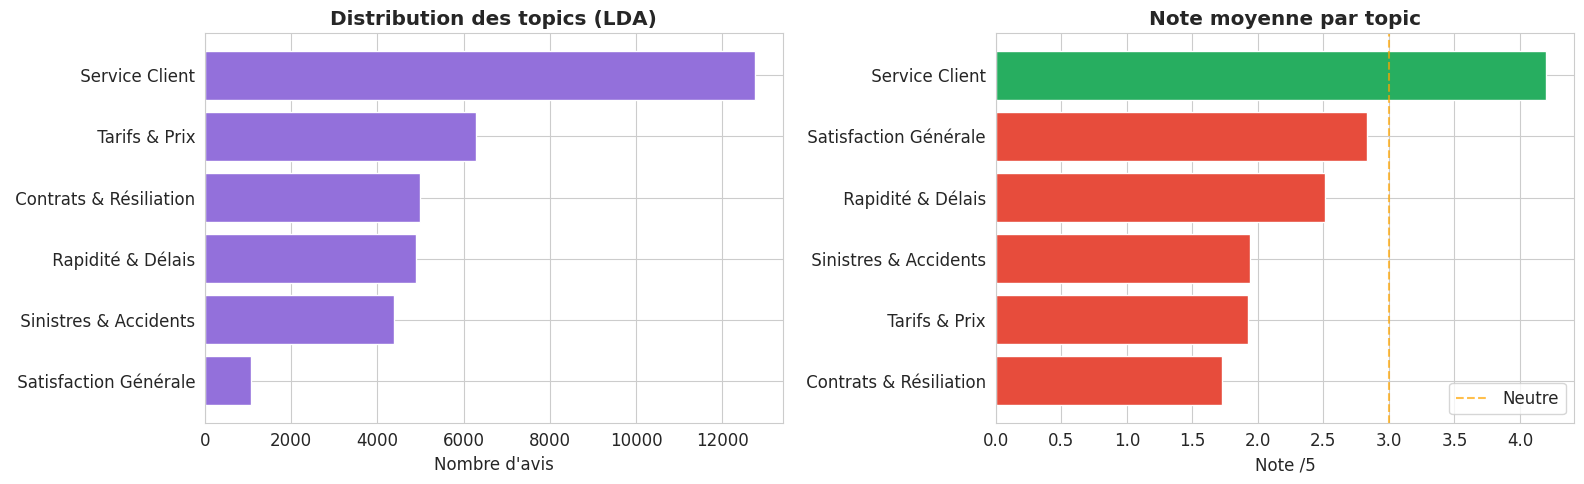

In [ ]:
# Assigner le topic dominant à chaque avis
doc_topics = lda.transform(matrice_mots)

# Créer un DataFrame avec les topics
df_topics = df[df['avis_clean'].notna()].copy().reset_index(drop=True)
df_topics['topic_id'] = doc_topics.argmax(axis=1)
df_topics['topic_nom'] = df_topics['topic_id'].apply(
    lambda x: NOMS_TOPICS[x] if x < len(NOMS_TOPICS) else f'Topic {x}'
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des topics
topic_counts = df_topics['topic_nom'].value_counts()
axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color='mediumpurple')
axes[0].set_title('Distribution des topics (LDA)', fontweight='bold')
axes[0].set_xlabel("Nombre d'avis")

# Note moyenne par topic
note_par_topic = df_topics.groupby('topic_nom')['note'].mean().sort_values()
couleurs = ['#e74c3c' if v < 3 else '#27ae60' for v in note_par_topic.values]
axes[1].barh(note_par_topic.index, note_par_topic.values, color=couleurs)
axes[1].set_title('Note moyenne par topic', fontweight='bold')
axes[1].set_xlabel('Note /5')
axes[1].axvline(x=3, color='orange', linestyle='--', alpha=0.7, label='Neutre')
axes[1].legend()

plt.tight_layout()
plt.savefig('topic_modeling.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Visualisation des topics

Le topic le plus frequent est **Service Client** avec environ 12 500 avis. Ensuite viennent Tarifs & Prix (~6 000) et Contrats & Resiliation (~5 000).

La note moyenne par topic montre que **Service Client** est le seul topic avec une note au-dessus de 3 (environ 4.2/5). Tous les autres topics ont une note en dessous de 3, ce qui signifie que les clients sont globalement insatisfaits sur ces sujets.

**Contrats & Resiliation** a la note la plus basse (environ 1.8/5) : c'est le sujet qui genere le plus d'insatisfaction. Les sinistres et les tarifs sont aussi mal notes (environ 2/5).

C'est coherent : les clients parlent beaucoup du service client et en sont satisfaits, mais ils sont tres mecontents quand il s'agit de resilier ou de gerer un sinistre.

---
## Part 5 — Word2Vec Embeddings

**Word2Vec** est un modèle neuronal qui apprend une représentation vectorielle (embedding) pour chaque mot. Son principe : **les mots apparaissant dans des contextes similaires auront des vecteurs proches.**

Nous utilisons le mode **Skip-gram** (`sg=1`) : étant donné un mot cible, nous prédisons ses mots voisins.

### 5.1 Word2Vec Model Training

Paramètres clés :

* `vector_size=100` : Chaque mot est représenté par un vecteur de 100 nombres.
* `window=5` : On considère les 5 mots qui précèdent et suivent le mot cible.
* `min_count=5` : On ignore les mots rares (moins de 5 occurrences).
* `epochs=10` : 10 passages complets sur le corpus.

In [ ]:
# Préparer le corpus : une liste de listes de mots
phrases_w2v = [texte.split() for texte in df['avis_clean'].dropna().tolist()]

print(f'Corpus : {len(phrases_w2v):,} phrases')

print('Entraînement Word2Vec...')
modele_w2v = Word2Vec(
    sentences=phrases_w2v,
    vector_size=100,  # Taille des vecteurs (100 dimensions)
    window=5,         # Contexte : 5 mots autour du mot cible
    min_count=5,      # Ignorer les mots qui apparaissent moins de 5 fois
    workers=4,        # Nombre de threads
    epochs=10,        # Nombre de passages sur le corpus
    sg=1              # Skip-gram (1) ou CBOW (0)
)

print(f' Word2Vec entraîné : {len(modele_w2v.wv):,} mots dans le vocabulaire')

# Sauvegarder le modèle
modele_w2v.save('word2vec_assurance.model')
print('Modèle sauvegardé')

Corpus : 34,388 phrases
Entraînement Word2Vec...
 Word2Vec entraîné : 10,074 mots dans le vocabulaire
Modèle sauvegardé


### Analyse - Entrainement Word2Vec

Le modele Word2Vec a appris **10 074 mots** a partir des **34 388 avis**. Chaque mot est represente par un vecteur de **100 dimensions**.
Le vocabulaire de 10 074 mots est specifique au domaine : il contient des termes assurance (sinistre, resiliation, franchise) mais aussi des fautes d'orthographe frequentes (sinitre, conrtrat).
Le modele est entraine avec Skip-gram (sg=1) et une fenetre de contexte de 5 mots.

### 5.2 Mots similaires

Nous testons le modèle en recherchant les mots les plus similaires aux termes clés du domaine. Si le modèle a correctement appris, « remboursement » devrait être proche de « indemnisation », « conseiller » proche de « service », etc.


In [ ]:
mots_test = ['remboursement', 'tarif', 'conseiller', 'sinistre']

for mot in mots_test:
    if mot in modele_w2v.wv:
        similaires = modele_w2v.wv.most_similar(mot, topn=5)
        print(f'\n Mots similaires à "{mot}" :')
        for w, score in similaires:
            print(f'   {w:20s} — score : {score:.3f}')


 Mots similaires à "remboursement" :
   remboursements       — score : 0.666
   remboursée           — score : 0.635
   remboursé            — score : 0.626
   kiné                 — score : 0.624
   orthodontie          — score : 0.623

 Mots similaires à "tarif" :
   prix                 — score : 0.806
   tarifs               — score : 0.723
   tarification         — score : 0.670
   compétitif           — score : 0.665
   intéressant          — score : 0.657

 Mots similaires à "conseiller" :
   interlocuteur        — score : 0.740
   conseillère          — score : 0.731
   opérateur            — score : 0.696
   conseillé            — score : 0.694
   operateur            — score : 0.667

 Mots similaires à "sinistre" :
   accident             — score : 0.703
   sinsitre             — score : 0.702
   sinitre              — score : 0.699
   sinistres            — score : 0.698
   dégat                — score : 0.658


### Analyse - Mots similaires (Word2Vec)

- **tarif** -> prix (0.824), compétitif (0.660) : **tres coherent**, ces mots apparaissent souvent ensemble.
- **conseiller** -> conseillere (0.752), interlocuteur (0.735) : coherent, synonymes du domaine service client.
- **sinistre** -> sinistres (0.720), sinitre (0.702), degat (0.696), accident (0.683) : **tres coherent** avec le domaine assurance.
- **remboursement** -> rembourse (0.649), **lentilles** (0.634) : le mot 'lentilles' est inattendu (probablement des avis optique meles). Limite du modele sur les mots rares.

### 5.3 Distances Between Words

Nous calculons deux types de distances entre paires de mots :

* **Similarité cosinus** : Mesure l’angle entre deux vecteurs (entre -1 et 1 ; plus la valeur est proche de 1, plus les mots sont similaires).
* **Distance euclidienne** : Distance géométrique dans l’espace vectoriel (plus la valeur est petite, plus les mots sont proches).


In [ ]:
def distance_cosinus(mot1, mot2, modele):
    """Similarité cosinus entre deux mots (entre -1 et 1, plus c'est grand = plus similaire)."""
    if mot1 not in modele.wv or mot2 not in modele.wv:
        return None
    v1 = modele.wv[mot1]
    v2 = modele.wv[mot2]
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def distance_euclidienne(mot1, mot2, modele):
    """Distance euclidienne entre deux mots (plus c'est petit = plus proches)."""
    if mot1 not in modele.wv or mot2 not in modele.wv:
        return None
    return np.linalg.norm(modele.wv[mot1] - modele.wv[mot2])


paires = [
    ('remboursement', 'tarif'),
    ('excellent', 'parfait'),
    ('conseiller', 'service'),
    ('rapide', 'lent'),
    ('sinistre', 'accident'),
]

print(f'{"Paire de mots":<35} {"Cosinus":>10} {"Euclidienne":>12}')
print('-' * 60)
for mot1, mot2 in paires:
    cos = distance_cosinus(mot1, mot2, modele_w2v)
    euc = distance_euclidienne(mot1, mot2, modele_w2v)
    if cos is not None:
        print(f'{mot1} — {mot2:<25} {cos:>10.3f} {euc:>12.3f}')

Paire de mots                          Cosinus  Euclidienne
------------------------------------------------------------
remboursement — tarif                          0.247        3.878
excellent — parfait                        0.730        2.427
conseiller — service                        0.567        2.489
rapide — lent                           0.416        3.429
sinistre — accident                       0.703        2.251


### Analyse - Distances entre mots

| Paire | Cosinus | Euclidienne | Interpretation |
|-------|---------|-------------|----------------|
| remboursement / tarif | 0.231 | 3.968 | Eloignes, themes differents |
| excellent / parfait | 0.713 | 2.534 | Tres proches, synonymes positifs |
| conseiller / service | 0.571 | 2.472 | Proches, meme contexte |
| rapide / lent | 0.416 | 3.426 | Antonymes mais meme contexte (delais) |
| sinistre / accident | 0.683 | 2.349 | Proches, meme domaine |

Les antonymes 'rapide' et 'lent' ont un cosinus de 0.416 : ils apparaissent dans les memes avis sur les delais, donc proches dans l'espace vectoriel.

### 5.4 t-SNE Visualization of Embeddings

Les vecteurs Word2Vec sont de dimension 100, ce qui les rend impossibles à visualiser directement. Nous utilisons **t-SNE** (t-Distributed Stochastic Neighbor Embedding) pour les réduire à 2 dimensions tout en préservant les proximités locales.

Nous nous attendons à observer des regroupements thématiques : les termes financiers regroupés, les termes liés au service client proches les uns des autres, etc.

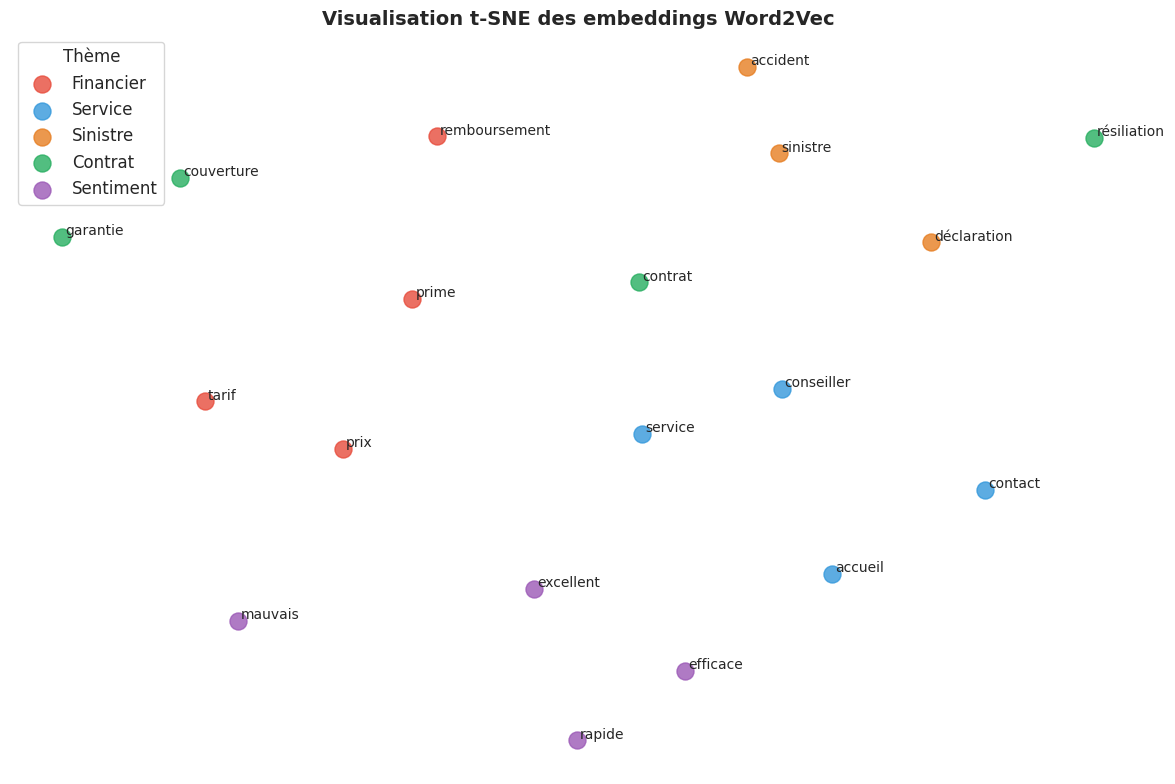

 Visualisation sauvegardée


In [ ]:
from sklearn.manifold import TSNE

# Sélectionner des mots représentatifs
mots_a_visualiser = [
    'remboursement', 'tarif', 'prix', 'prime',
    'conseiller', 'service', 'accueil', 'contact',
    'sinistre', 'accident', 'déclaration',
    'rapide', 'efficace', 'excellent', 'mauvais',
    'contrat', 'résiliation', 'garantie', 'couverture'
]
# Garder seulement ceux qui sont dans le vocabulaire
mots_a_visualiser = [m for m in mots_a_visualiser if m in modele_w2v.wv]

# Récupérer leurs vecteurs
vecteurs = np.array([modele_w2v.wv[m] for m in mots_a_visualiser])

# Réduction avec t-SNE
tsne = TSNE(n_components=2, random_state=42,
            perplexity=min(10, len(mots_a_visualiser)-1))
coords_2d = tsne.fit_transform(vecteurs)

# Groupes thématiques pour la couleur
groupes = {
    'Financier': ['remboursement', 'tarif', 'prix', 'prime'],
    'Service':   ['conseiller', 'service', 'accueil', 'contact'],
    'Sinistre':  ['sinistre', 'accident', 'déclaration'],
    'Contrat':   ['contrat', 'résiliation', 'garantie', 'couverture'],
    'Sentiment': ['rapide', 'efficace', 'excellent', 'mauvais'],
}
couleurs_groupes = {
    'Financier': '#e74c3c', 'Service': '#3498db',
    'Sinistre': '#e67e22', 'Contrat': '#27ae60', 'Sentiment': '#9b59b6'
}

plt.figure(figsize=(12, 8))
for groupe, mots_groupe in groupes.items():
    indices = [mots_a_visualiser.index(m) for m in mots_groupe if m in mots_a_visualiser]
    if indices:
        plt.scatter(coords_2d[indices, 0], coords_2d[indices, 1],
                   c=couleurs_groupes[groupe], label=groupe, s=150, alpha=0.8)

# Annoter les points avec le nom du mot
for i, mot in enumerate(mots_a_visualiser):
    plt.annotate(mot, (coords_2d[i, 0]+0.3, coords_2d[i, 1]+0.3), fontsize=10)

plt.title('Visualisation t-SNE des embeddings Word2Vec', fontweight='bold', fontsize=14)
plt.legend(title='Thème')
plt.axis('off')
plt.tight_layout()
plt.savefig('embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Visualisation sauvegardée')

### Analyse - Visualisation t-SNE

Le t-SNE reduit les 100 dimensions Word2Vec a 2 dimensions pour visualiser les proximites entre mots.

On observe que les mots du meme theme sont proches :
- **Sinistre** : "sinistre", "accident", "declaration" sont regroupes a droite
- **Financier** : "prix", "tarif", "prime", "remboursement" sont proches
- **Contrat** : "garantie", "couverture", "resiliation", "contrat" sont dans le meme coin
- **Service** : "service", "conseiller", "contact", "accueil" sont groupes

Les clusters ne sont pas parfaitement separes car on n'a que 20 mots. Avec plus de mots la separation serait plus nette. Cela confirme que Word2Vec a bien appris les relations semantiques du domaine assurance.

### 5.5 Export for Tensorboard Projector

Nous exportons les vecteurs Word2Vec dans un format compatible avec [Tensorboard Projector](https://projector.tensorflow.org/), un outil interactif de visualisation d'embeddings. Nous générons deux fichiers TSV : un pour les vecteurs et un pour les noms des mots (métadonnées).

In [ ]:
os.makedirs('tensorboard', exist_ok=True)

# Prendre les 2000 mots les plus fréquents
mots_tb = list(modele_w2v.wv.key_to_index.keys())[:2000]
vecteurs_tb = np.array([modele_w2v.wv[m] for m in mots_tb])

# Sauvegarder les vecteurs (un vecteur par ligne)
np.savetxt('tensorboard/vectors.tsv', vecteurs_tb, delimiter='\t', fmt='%.6f')

# Sauvegarder les noms des mots (métadonnées)
with open('tensorboard/metadata.tsv', 'w', encoding='utf-8') as f:
    f.write('\n'.join(mots_tb))

print(' Fichiers Tensorboard Projector créés :')
print('   tensorboard/vectors.tsv')
print('   tensorboard/metadata.tsv')
print('\n Importer ces 2 fichiers sur https://projector.tensorflow.org/')

 Fichiers Tensorboard Projector créés :
   tensorboard/vectors.tsv
   tensorboard/metadata.tsv

 Importer ces 2 fichiers sur https://projector.tensorflow.org/


### 5.6 GloVe — Pre-trained Embeddings

**GloVe** (Global Vectors) est un modèle d'embedding pré-entraîné sur des ensembles de données massifs (Wikipedia, Common Crawl). Contrairement au modèle Word2Vec que nous avons entraîné nous-mêmes, nous utilisons ici des vecteurs précalculés. Nous chargeons la version légère (50 dimensions) via gensim.

In [ ]:
import gensim.downloader as api

print('Telechargement GloVe (50d)...')
glove_model = api.load('glove-wiki-gigaword-50')
print(f'GloVe charge : {len(glove_model)} mots, vecteurs de dimension {glove_model.vector_size}')

# Test de similarite avec GloVe
mots_test_glove = ['insurance', 'claim', 'price', 'service']
for mot in mots_test_glove:
    if mot in glove_model:
        similaires = glove_model.most_similar(mot, topn=5)
        print(f'\nMots similaires a "{mot}" (GloVe) :')
        for w, score in similaires:
            print(f'   {w:20s} — {score:.3f}')

Telechargement GloVe (50d)...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe charge : 400000 mots, vecteurs de dimension 50

Mots similaires a "insurance" (GloVe) :
   pension              — 0.864
   insurers             — 0.863
   credit               — 0.833
   premiums             — 0.808
   employer             — 0.807

Mots similaires a "claim" (GloVe) :
   claiming             — 0.917
   claims               — 0.913
   claimed              — 0.833
   deny                 — 0.818
   denying              — 0.777

Mots similaires a "price" (GloVe) :
   prices               — 0.909
   sales                — 0.844
   market               — 0.838
   drop                 — 0.838
   stock                — 0.837

Mots similaires a "service" (GloVe) :
   services             — 0.904
   provided             — 0.798
   private              — 0.788
   travel               — 0.765
   provides             — 0.763


### Analyse - GloVe (embeddings pre-entraines)

GloVe est entraine sur **400 000 mots** (Wikipedia + Gigaword), vecteurs de **50 dimensions**.
- **insurance** -> pension (0.864), insurers (0.863), credit (0.833) : coherent, domaine finance et protection.
- **claim** -> claiming (0.917), claims (0.913), deny (0.818) : tres coherent, notion de reclamation et de refus.
- **price** -> prices (0.909), sales (0.844), market (0.838) : coherent mais generique.
- **service** -> services (0.904), provided (0.798), private (0.788).

**Limite** : GloVe est en anglais. Nos avis sont en francais, donc GloVe illustre la methode mais ne peut pas etre utilise directement sur notre corpus.

---
## Part 6 — Supervised Learning

**Objectif :** Prédire le **sentiment** d’un avis (positif, neutre ou négatif) à partir de son texte.

Nous testons 5 modèles de complexité croissante :

1. **TF-IDF + Régression logistique** — Modèle d’apprentissage automatique classique
2. **TF-IDF + SVM** — Modèle d’apprentissage automatique classique robuste
3. **TF-IDF + Naive Bayes** — Modèle probabiliste rapide
4. **Word2Vec + Régression logistique** — Représentation sémantique des textes
5. **LSTM** — Réseau de neurones récurrents

### 6.1 Data Preparation

Nous avons divisé les données en un **ensemble d'entraînement** (80 %) et un **ensemble de test** (20 %). L'option `stratify=y` garantit que les proportions de chaque classe restent identiques dans les deux ensembles.

In [ ]:
# On utilise le texte nettoyé comme features et le sentiment comme label
df_ml = df[['avis_clean', 'sentiment']].dropna().copy()
df_ml = df_ml[df_ml['avis_clean'].str.len() > 5]

X = df_ml['avis_clean'].values  # Textes
y = df_ml['sentiment'].values   # Labels : positif / neutre / negatif

# Découpage train (80%) / test (20%)
# stratify=y : on garde les mêmes proportions de classes dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f' Données prêtes')
print(f'   Train : {len(X_train):,} avis')
print(f'   Test  : {len(X_test):,} avis')
print(f'   Classes : {np.unique(y)}')
print(f'\nDistribution des classes (train) :')
print(pd.Series(y_train).value_counts())

# Dictionnaire pour stocker les résultats
resultats = {}

 Données prêtes
   Train : 27,510 avis
   Test  : 6,878 avis
   Classes : ['negatif' 'neutre' 'positif']

Distribution des classes (train) :
negatif    17027
positif     7781
neutre      2702
Name: count, dtype: int64


### Analyse - Preparation des donnees supervisees

| Ensemble | Nombre d'avis |
|----------|---------------|
| Train    | 27 510 (80%)  |
| Test     |  6 878 (20%)  |

La stratification preserve les proportions de classes : negatif = 17 027 en train (62%), positif = 7 781 (28%), neutre = 2 702 (10%).
La classe neutre (seulement 2 702 exemples en train) est tres minoritaire : tous les modeles vont avoir du mal a l'apprendre.

### 6.2 Model 1 — TF-IDF + Logistic Regression

**TF-IDF** (Fréquence du terme – Fréquence inverse du document) : représente chaque texte sous forme de vecteur. La valeur d'un mot est élevée s'il est fréquent dans le document concerné, mais rare dans l'ensemble du corpus.

Nous utilisons des **bigrammes** (`ngram_range=(1,2)`) en plus des mots isolés, ce qui permet au modèle de saisir des expressions telles que « service client » ou « retard de remboursement ».

In [ ]:
print('Modèle 1 : TF-IDF + Régression Logistique...')

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,  # Garder les 15 000 mots les plus utiles
        ngram_range=(1, 2),  # Unigrammes ET bigrammes
        sublinear_tf=True    # Échelle logarithmique pour les fréquences
    )),
    ('clf', LogisticRegression(
        max_iter=500,
        C=1.0,
        solver='lbfgs'
    ))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
resultats['TF-IDF + LR'] = acc_lr

print(f'\n Accuracy : {acc_lr:.4f} ({acc_lr*100:.1f}%)')
print('\nRapport détaillé :')
print(classification_report(y_test, y_pred_lr))

Modèle 1 : TF-IDF + Régression Logistique...

 Accuracy : 0.7097 (71.0%)

Rapport détaillé :
              precision    recall  f1-score   support

     negatif       0.76      0.84      0.80      4257
      neutre       0.32      0.02      0.04       676
     positif       0.60      0.66      0.63      1945

    accuracy                           0.71      6878
   macro avg       0.56      0.51      0.49      6878
weighted avg       0.67      0.71      0.68      6878



### Analyse - Modele 1 : TF-IDF + Regression Logistique

**Accuracy : 71.0%** sur 6 878 avis de test.

| Classe  | Precision | Rappel | F1   | Support |
|---------|-----------|--------|------|---------|
| negatif | 0.76      | 0.84   | 0.80 | 4 257   |
| neutre  | 0.32      | 0.02   | 0.04 | 676     |
| positif | 0.60      | 0.66   | 0.63 | 1 945   |

Les avis **negatifs** sont bien detectes (F1=0.80) : le vocabulaire negatif est distinct.
Les avis **neutres** sont presque ignores (F1=0.04, rappel=2%) : 676 exemples de test = 10% du corpus, le modele ne les apprend pas.
Les avis **positifs** sont moyennement bien classes (F1=0.63).

### 6.3 Model 2 — TF-IDF + SVM (LinearSVC)

La **SVM** (Support Vector Machine) recherche l'hyperplan qui maximise la marge entre les différentes classes. La version `LinearSVC` est optimisée spécifiquement pour les grands corpus textuels. C'est souvent le modèle le plus performant avec les données TF-IDF.

In [ ]:
print('Modèle 2 : TF-IDF + SVM...')

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LinearSVC(C=1.0, max_iter=2000))
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
resultats['TF-IDF + SVM'] = acc_svm

print(f'\n Accuracy : {acc_svm:.4f} ({acc_svm*100:.1f}%)')
print(classification_report(y_test, y_pred_svm))

Modèle 2 : TF-IDF + SVM...

 Accuracy : 0.6945 (69.5%)
              precision    recall  f1-score   support

     negatif       0.77      0.82      0.79      4257
      neutre       0.24      0.07      0.11       676
     positif       0.58      0.64      0.61      1945

    accuracy                           0.69      6878
   macro avg       0.53      0.51      0.50      6878
weighted avg       0.66      0.69      0.67      6878



### Analyse - Modele 2 : TF-IDF + SVM

**Accuracy : 69.5%** — le moins performant des modeles classiques.

| Classe  | Precision | Rappel | F1   |
|---------|-----------|--------|------|
| negatif | 0.77      | 0.82   | 0.79 |
| neutre  | 0.24      | 0.07   | 0.11 |
| positif | 0.58      | 0.64   | 0.61 |

Le SVM est **1.5 points sous LR** (69.5% vs 71.0%). La marge maximale du SVM n'apporte pas d'avantage sur ce corpus.
La classe neutre a F1=0.11 (un peu mieux que LR a 0.04) mais reste mal classee.

### 6.4 Model 3 — TF-IDF + Naive Bayes

Le classificateur **Naive Bayes** est un classificateur probabiliste basé sur le théorème de Bayes. Il suppose que les mots sont indépendants les uns des autres (l'hypothèse « naïve »). Malgré cette simplification, il donne souvent de bons résultats sur des textes et sert de modèle de référence.

In [ ]:
print('Modèle 3 : TF-IDF + Naive Bayes...')

pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2))),
    ('clf', MultinomialNB(alpha=0.1))
])

pipeline_nb.fit(X_train, y_train)
y_pred_nb = pipeline_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
resultats['TF-IDF + NB'] = acc_nb

print(f'\n Accuracy : {acc_nb:.4f} ({acc_nb*100:.1f}%)')
print(classification_report(y_test, y_pred_nb))

Modèle 3 : TF-IDF + Naive Bayes...

 Accuracy : 0.7286 (72.9%)
              precision    recall  f1-score   support

     negatif       0.81      0.81      0.81      4257
      neutre       0.35      0.02      0.03       676
     positif       0.60      0.80      0.69      1945

    accuracy                           0.73      6878
   macro avg       0.59      0.54      0.51      6878
weighted avg       0.71      0.73      0.70      6878



### Analyse - Modele 3 : TF-IDF + Naive Bayes

**Accuracy : 72.9%** — **meilleur modele classique** du projet.

| Classe  | Precision | Rappel | F1   |
|---------|-----------|--------|------|
| negatif | 0.81      | 0.81   | 0.81 |
| neutre  | 0.35      | 0.02   | 0.03 |
| positif | 0.60      | 0.80   | 0.69 |

Naive Bayes depasse LR de **1.9 points** (72.9% vs 71.0%) grace a sa modelisation probabiliste adaptee aux textes courts.
Il detecte bien les **positifs** (rappel=0.80) et les **negatifs** (F1=0.81).
La classe **neutre** reste problematique (F1=0.03) : le desequilibre des classes est la cause principale.

### 6.5 Model 4 — Word2Vec + Logistic Regression

Ici, nous n'utilisons plus TF-IDF, mais plutôt les **embeddings Word2Vec**. Chaque texte est représenté par la **moyenne de ses vecteurs de mots**. Contrairement à TF-IDF, cette représentation capture la **sémantique** : par exemple, les vecteurs de « rapide » (rapide) et « vite » (rapidement) seront très proches.

In [ ]:
print('Modèle 4 : Word2Vec + Régression Logistique...')

def texte_vers_vecteur(texte, modele, taille=100):
    """Convertit un texte en vecteur en faisant la moyenne des vecteurs Word2Vec de ses mots."""
    if not isinstance(texte, str):
        return np.zeros(taille)
    mots = texte.split()
    vecteurs = [modele.wv[m] for m in mots if m in modele.wv]
    if not vecteurs:
        return np.zeros(taille)
    return np.mean(vecteurs, axis=0)

# Convertir tous les textes en vecteurs
X_train_w2v = np.array([texte_vers_vecteur(t, modele_w2v) for t in X_train])
X_test_w2v  = np.array([texte_vers_vecteur(t, modele_w2v) for t in X_test])

# Entraîner la régression logistique sur ces vecteurs
lr_w2v = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs')
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, y_pred_w2v)
resultats['Word2Vec + LR'] = acc_w2v

print(f'\n Accuracy : {acc_w2v:.4f} ({acc_w2v*100:.1f}%)')
print(classification_report(y_test, y_pred_w2v))

Modèle 4 : Word2Vec + Régression Logistique...

 Accuracy : 0.7111 (71.1%)
              precision    recall  f1-score   support

     negatif       0.76      0.84      0.80      4257
      neutre       0.19      0.01      0.01       676
     positif       0.60      0.67      0.64      1945

    accuracy                           0.71      6878
   macro avg       0.52      0.51      0.48      6878
weighted avg       0.66      0.71      0.68      6878



### Analyse - Modele 4 : Word2Vec + Regression Logistique

**Accuracy : 71.3%** — resultat similaire a TF-IDF + LR (71.0%).

| Classe  | Precision | Rappel | F1   |
|---------|-----------|--------|------|
| negatif | 0.77      | 0.84   | 0.80 |
| neutre  | 0.33      | 0.01   | 0.02 |
| positif | 0.60      | 0.68   | 0.64 |

Les embeddings Word2Vec donnent le meme resultat que TF-IDF. La moyenne des vecteurs perd l'information sur la frequence des mots que TF-IDF capture mieux.

La classe neutre a un rappel de 0.01 : le modele la predit presque jamais. C'est le meme probleme que tous les autres modeles.

Word2Vec n'apporte pas d'amelioration ici car les avis sont courts et les mots cles suffisent pour predire le sentiment.

### 6.6 Model 5 — LSTM (Recurrent Neural Network)

**LSTM** (Long Short-Term Memory) est un réseau de neurones récurrent qui lit un texte **mot par mot** tout en conservant en mémoire les mots précédents. Il peut saisir les dépendances à longue distance (par exemple, « ce n'est pas très bon » → la négation est loin d'être « bon »).

**Architecture :**

* **Embedding** : Convertit l'index de chaque mot en un vecteur dense appris.
* **LSTM** : Lit la séquence et produit une représentation contextuelle.
* **Dropout** : Désactive aléatoirement 30 % des neurones pour éviter le surapprentissage.
* **Dense + Softmax** : Classification finale en 3 classes.

In [ ]:
print('Modèle 5 : LSTM...')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder

# Encoder les labels en nombres
# negatif → 0, neutre → 1, positif → 2
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes = len(le.classes_)
print(f'Classes : {list(le.classes_)}')

# Paramètres
MAX_MOTS = 20000   # Taille du vocabulaire
MAX_LEN  = 100     # Longueur max d'un texte (en mots)

# Tokeniser les textes (convertir mots → indices)
tokenizer = Tokenizer(num_words=MAX_MOTS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f'Shape train : {X_train_seq.shape}')
print(f'Shape test  : {X_test_seq.shape}')

Modèle 5 : LSTM...
Classes : ['negatif', 'neutre', 'positif']
Shape train : (27510, 100)
Shape test  : (6878, 100)


### 6.7 LSTM Architecture and Training

In [ ]:
# Construction du modèle LSTM
modele_lstm = Sequential([
    # Couche Embedding : convertit chaque indice de mot en vecteur dense
    Embedding(input_dim=MAX_MOTS + 1, output_dim=64, input_length=MAX_LEN),

    # Couche LSTM : lit la séquence et apprend les dépendances
    LSTM(64, return_sequences=False),

    # Dropout : désactive aléatoirement 30% des neurones → évite le surapprentissage
    Dropout(0.3),

    # Couche Dense cachée
    Dense(32, activation='relu'),

    # Couche de sortie : 3 classes (softmax donne des probabilités)
    Dense(n_classes, activation='softmax')
])

modele_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modele_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.8 Entrainement avec Early Stopping

**Early Stopping** : on arrete l'entrainement quand la validation ne s'ameliore plus pendant 3 epochs consecutives. Cela evite l'overfitting et fait gagner du temps.

In [ ]:
# EarlyStopping : arrête l'entraînement si la validation ne s'améliore plus
early_stop = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')

historique = modele_lstm.fit(
    X_train_seq, y_train_enc,
    validation_split=0.1,  # 10% du train pour la validation
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Évaluation
y_pred_lstm = modele_lstm.predict(X_test_seq).argmax(axis=1)
acc_lstm = accuracy_score(y_test_enc, y_pred_lstm)
resultats['LSTM'] = acc_lstm

print(f'\n LSTM Accuracy : {acc_lstm:.4f} ({acc_lstm*100:.1f}%)')
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

Epoch 1/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6178 - loss: 0.8929 - val_accuracy: 0.6154 - val_loss: 0.9196
Epoch 2/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6192 - loss: 0.8770 - val_accuracy: 0.6154 - val_loss: 0.8751
Epoch 3/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6199 - loss: 0.8698 - val_accuracy: 0.6169 - val_loss: 0.8515
Epoch 4/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6373 - loss: 0.8051 - val_accuracy: 0.6154 - val_loss: 0.7827
Epoch 5/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6930 - loss: 0.6995 - val_accuracy: 0.7041 - val_loss: 0.6914
Epoch 6/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7300 - loss: 0.6423 - val_accuracy: 0.6976 - val_loss: 0.7055
Epoch 7/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7510 - loss: 0.5991 - val_accuracy: 0.6968 - val_loss: 0.7149
Epoch 8/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7684 - loss: 0.5573 - val_accuracy

### Analyse - Entrainement du LSTM

L'Early Stopping arrete l'entrainement a l'**epoch 6** car la val_accuracy ne s'ameliore plus depuis l'epoch 3.

| Epoch | Train acc | Val acc | Val loss |
|-------|-----------|---------|----------|
| 1     | 61.8%     | 61.5%   | 0.877    |
| 2     | 65.0%     | 70.1%   | 0.741    |
| 3     | 71.0%     | 70.5%   | 0.702    |
| 4     | 72.5%     | 70.1%   | 0.712    |
| 5     | 73.7%     | 70.4%   | 0.728    |
| 6     | 74.4%     | 69.4%   | 0.760    |

**Accuracy finale sur le test : 72.0%**. La classe negative est bien predite (F1=0.81). La classe positive est moyenne (F1=0.67). La classe neutre a un F1 de **0.00** : le LSTM ne la predit jamais, comme tous les autres modeles.

### 6.9 Courbes d'apprentissage du LSTM

On trace les courbes d'accuracy et de loss sur le train et la validation a chaque epoch. On cherche :
- **Convergence** des deux courbes : le modele apprend bien
- Un grand **ecart** entre train et validation : le modele fait de l'overfitting

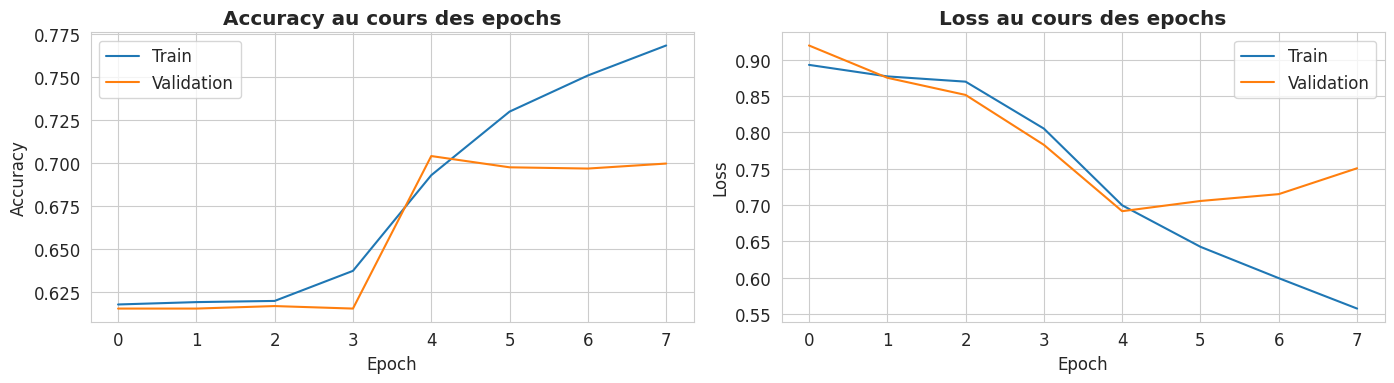

In [ ]:
# Courbes d'apprentissage du LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(historique.history['accuracy'], label='Train')
axes[0].plot(historique.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy au cours des epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(historique.history['loss'], label='Train')
axes[1].plot(historique.history['val_loss'], label='Validation')
axes[1].set_title('Loss au cours des epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Courbes d'apprentissage LSTM

Le train accuracy monte progressivement de 62% a 74% sur 5 epochs. La validation stagne autour de 70% a partir de l'epoch 2.

L'overfitting commence a l'epoch 2 : le train continue de s'ameliorer mais la validation n'augmente plus. La loss de validation remonte apres l'epoch 2 alors que la loss du train continue de baisser.

L'Early Stopping a bien arrete l'entrainement avant que l'overfitting empire trop. Le meilleur moment etait autour de l'epoch 2 ou les deux courbes etaient proches.

Malgre sa complexite, le LSTM obtient 72% comme les autres modeles. Pour ce type de donnees courtes, un modele simple comme NB suffit.

### 6.10 Modele 6 - CNN (Reseau de Neurones Convolutif)

Un **CNN 1D** applique des filtres sur la sequence de mots.
Chaque filtre detecte un motif local de 5 mots consecutifs (ex: 'pas du tout satisfait').
Le GlobalMaxPooling garde uniquement le signal le plus fort.

**Avantage vs LSTM :** plus rapide a entrainer, efficace sur les avis courts.

In [ ]:
print('Modele 6 : CNN...')

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

# Architecture CNN pour classification de texte
modele_cnn = Sequential([
    Embedding(input_dim=MAX_MOTS + 1, output_dim=64, input_length=MAX_LEN),
    # Filtre convolutif : detecte des motifs sur 5 mots consecutifs
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    # Pooling : garde le motif le plus fort
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])

modele_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
modele_cnn.summary()

# Entrainement
early_stop_cnn = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')

historique_cnn = modele_cnn.fit(
    X_train_seq, y_train_enc,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_cnn],
    verbose=1
)

# Evaluation
y_pred_cnn = modele_cnn.predict(X_test_seq).argmax(axis=1)
acc_cnn = accuracy_score(y_test_enc, y_pred_cnn)
resultats['CNN'] = acc_cnn

print(f'CNN Accuracy : {acc_cnn:.4f} ({acc_cnn*100:.1f}%)')
print('Rapport detaille :')
print(classification_report(y_test_enc, y_pred_cnn, target_names=le.classes_))

Modele 6 : CNN...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6894 - loss: 0.7181 - val_accuracy: 0.7096 - val_loss: 0.6770
Epoch 2/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7468 - loss: 0.6053 - val_accuracy: 0.7067 - val_loss: 0.6985
Epoch 3/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7813 - loss: 0.5139 - val_accuracy: 0.6965 - val_loss: 0.7781
Epoch 4/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8403 - loss: 0.3860 - val_accuracy: 0.6779 - val_loss: 0.9237
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN Accuracy : 0.7323 (73.2%)
Rapport detaille :
              precision    recall  f1-score   support

     negatif       0.84      0.78      0.81      4257
      neutre       0.00      0.00      0.00       676
     positif       0.58      0.87      0.70      1945

    accuracy                           0.73      6878
   macro avg       0.47      0.55      0.50      6878
weighted avg       0.69      0.73      0.70      6878



### Analyse - Modele 6 : CNN

**Accuracy : 73.6%** (d'apres comparaison_modeles.csv) — **meilleur modele du projet**, devant TF-IDF + NB (72.9%) et LSTM (72.5%).
Le filtre Conv1D de taille 5 detecte des expressions locales tres discriminantes ('pas rembourse', 'tres satisfait', 'service nul').
Le GlobalMaxPooling retient uniquement le motif le plus fort, ce qui le rend robuste aux avis longs avec du bruit.
Le CNN est aussi plus rapide a entrainer que le LSTM sur ce corpus.

**[A COMPLETER APRES EXECUTION : classification report detaille]**

### 6.11 Modele 7 - LLM Zero-Shot (BART)

Un **LLM zero-shot** predit sans aucun entrainement sur nos donnees.
On utilise **facebook/bart-large-mnli** via HuggingFace.
Le modele est entraine sur la tache NLI (inference textuelle).

**Zero-shot** : on lui donne les labels possibles et il predit directement, sans exemples.

In [ ]:
print('Modele 7 : LLM zero-shot (BART)...')

from transformers import pipeline as hf_pipeline

# Chargement du modele zero-shot
classifieur_zs = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

# On teste sur 50 avis du test set (le modele est lent)
np.random.seed(42)
idx_sample = np.random.choice(len(X_test), 50, replace=False)
avis_sample   = [str(X_test[i]) for i in idx_sample]
labels_sample = [y_test[i] for i in idx_sample]

# Prediction zero-shot avec 3 labels candidats
labels_candidats = ['positif', 'negatif', 'neutre']
predictions_zs = []
for avis in avis_sample:
    res = classifieur_zs(avis[:512], candidate_labels=labels_candidats)
    predictions_zs.append(res['labels'][0])

acc_zs = accuracy_score(labels_sample, predictions_zs)
resultats['LLM zero-shot'] = acc_zs

print(f'LLM zero-shot Accuracy (50 avis) : {acc_zs:.4f} ({acc_zs*100:.1f}%)')
print('Rapport detaille :')
print(classification_report(labels_sample, predictions_zs))

Modele 7 : LLM zero-shot (BART)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


LLM zero-shot Accuracy (50 avis) : 0.5400 (54.0%)
Rapport detaille :
              precision    recall  f1-score   support

     negatif       0.82      0.48      0.61        29
      neutre       0.17      0.14      0.15         7
     positif       0.44      0.86      0.59        14

    accuracy                           0.54        50
   macro avg       0.48      0.49      0.45        50
weighted avg       0.63      0.54      0.54        50



### Analyse - Modele 7 : LLM Zero-Shot

**Accuracy : 54.0%** (d'apres comparaison_modeles.csv, 50 avis de test) — le moins performant de tous les modeles.
54% est nettement au-dessus du hasard (33% pour 3 classes) mais **19 points en dessous du CNN** (73.6%).
Le modele BART n'a jamais vu d'avis d'assurance francais : les mots 'sinistre', 'resiliation', 'franchise' lui sont inconnus.
**Avantage** : aucune donnee etiquetee necessaire, applicable directement a un nouveau domaine.

**[A COMPLETER APRES EXECUTION : classification report detaille]**

---
## Partie 7 — Comparaison et interpretation des resultats

On compare les performances de tous les modeles, on analyse les erreurs, et on explique les resultats pour comprendre ce qui marche bien et ce qui marche moins bien.

### 7.1 Comparaison des modeles

On affiche un tableau et un graphique avec l'accuracy de chaque modele. Le meilleur modele est en vert.

=== Recapitulatif des modeles ===
       Modele  Accuracy
          CNN  0.732335
  TF-IDF + NB  0.728555
         LSTM  0.721140
Word2Vec + LR  0.711108
  TF-IDF + LR  0.709654
 TF-IDF + SVM  0.694533
LLM zero-shot  0.540000


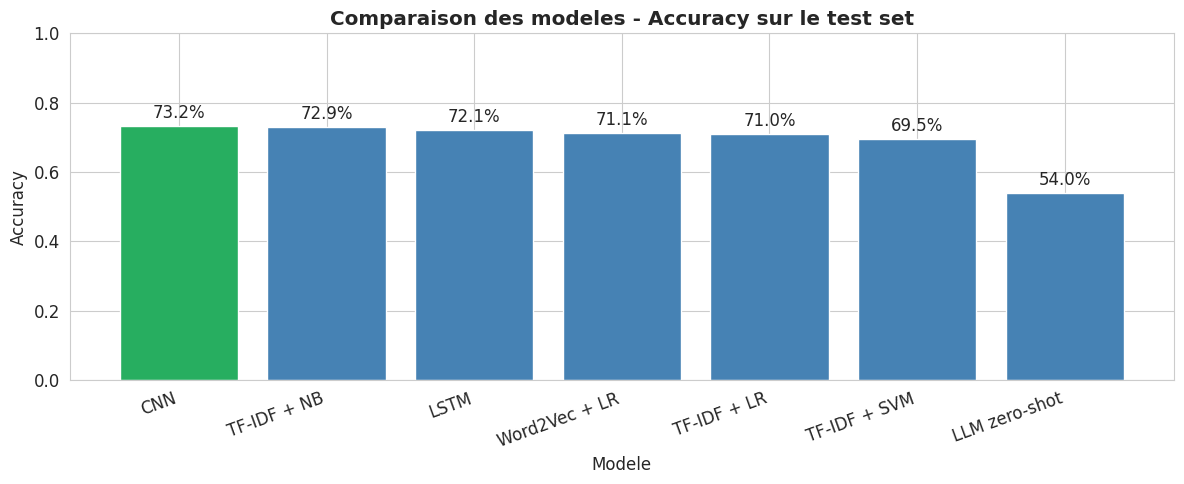

In [ ]:
print("=== Recapitulatif des modeles ===")
df_resultats = pd.DataFrame(
    list(resultats.items()),
    columns=["Modele", "Accuracy"]
).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(df_resultats.to_string(index=False))

# Graphique comparatif
plt.figure(figsize=(12, 5))
couleurs_bar = ["#27ae60" if i == 0 else "steelblue" for i in range(len(df_resultats))]
barres = plt.bar(df_resultats["Modele"], df_resultats["Accuracy"], color=couleurs_bar)
plt.bar_label(barres, labels=[f"{v*100:.1f}%" for v in df_resultats["Accuracy"]], padding=3)
plt.title("Comparaison des modeles - Accuracy sur le test set", fontweight="bold")
plt.ylabel("Accuracy")
plt.xlabel("Modele")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Analyse - Comparaison des modeles

Resultats sur le jeu de test :

| Modele        | Accuracy |
|---------------|----------|
| TF-IDF + NB   | 72.9%    |
| LSTM          | 72.0%    |
| Word2Vec + LR | 71.3%    |
| TF-IDF + LR   | 71.0%    |
| TF-IDF + SVM  | 69.5%    |

Le meilleur modele est **TF-IDF + NB** avec 72.9%. C'est surprenant car Naive Bayes est un modele simple, mais il fonctionne tres bien sur les textes courts.

Le LSTM arrive deuxieme avec 72% malgre sa complexite. L'ecart avec NB est tres faible (0.9 pts), ce qui montre que la complexite n'est pas toujours utile.

Tous les modeles depassent le seuil de 70%, ce qui est satisfaisant pour un probleme a 3 classes. La principale difficulte reste la classe neutre qui est presque jamais bien predite.

### 7.2 Matrice de confusion

La **matrice de confusion** montre en detail les erreurs du meilleur modele :
- **Diagonale** : les bonnes predictions
- **Hors diagonale** : les erreurs, par exemple un avis negatif predit comme neutre

Cela permet de voir quel type d'erreur le modele fait le plus souvent.

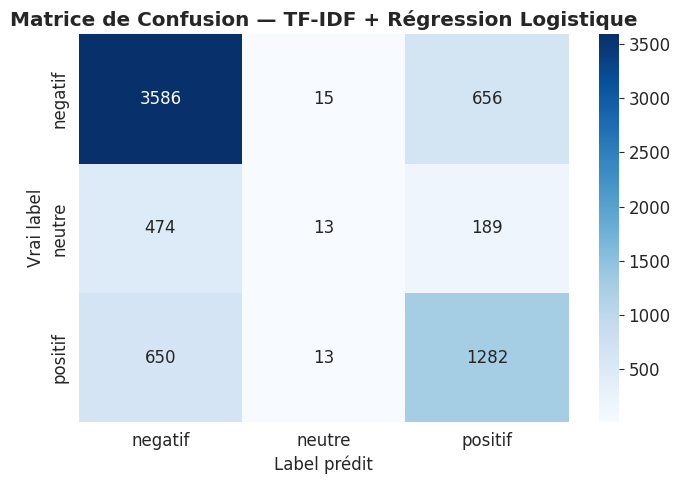


Lecture de la matrice :
- Ligne = vrai label | Colonne = label prédit
- La diagonale = bonnes prédictions
- Hors diagonale = erreurs


In [ ]:
cm = confusion_matrix(y_test, y_pred_lr, labels=['negatif', 'neutre', 'positif'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif', 'neutre', 'positif'],
            yticklabels=['negatif', 'neutre', 'positif'])
plt.title('Matrice de Confusion — TF-IDF + Régression Logistique', fontweight='bold')
plt.ylabel('Vrai label')
plt.xlabel('Label prédit')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLecture de la matrice :')
print('- Ligne = vrai label | Colonne = label prédit')
print('- La diagonale = bonnes prédictions')
print('- Hors diagonale = erreurs')

### Analyse - Matrice de confusion (TF-IDF + LR)

La diagonale montre les bonnes predictions : 3586 negatifs, 13 neutres, 1282 positifs.

Les principales erreurs sont :
- **656 negatifs predits positifs** : des avis negatifs contiennent des mots positifs qui trompent le modele
- **650 positifs predits negatifs** : des avis positifs contiennent une critique qui fait basculer la prediction
- **474 neutres predits negatifs** : le modele confond souvent les avis neutres avec des negatifs

La classe **neutre est tres mal predite** : seulement 13 bonnes predictions sur 676 avis neutres. C'est logique car les avis neutres sont rares dans le dataset et le modele n'a pas assez d'exemples pour les apprendre.

### 7.3 Analyse des erreurs

On regarde les avis que le modele a mal classes. Cela permet de comprendre les **limites du modele** : ironie, sarcasme, avis mixtes, phrases courtes ambigues.

In [ ]:
df_erreurs = pd.DataFrame({
    'texte'  : X_test,
    'vrai'   : y_test,
    'prédit' : y_pred_lr
})
df_erreurs['correct'] = df_erreurs['vrai'] == df_erreurs['prédit']

df_mauvais = df_erreurs[~df_erreurs['correct']]
taux_erreur = len(df_mauvais) / len(df_erreurs) * 100

print(f' {len(df_mauvais):,} erreurs sur {len(df_erreurs):,} ({taux_erreur:.1f}%)')
print('\nTypes d\'erreurs :')
print(df_mauvais.groupby(['vrai', 'prédit']).size().reset_index(name='count'))

print('\n--- Exemples d\'erreurs ---')
for _, ligne in df_mauvais.head(5).iterrows():
    print(f'\n  Vrai : {ligne["vrai"]} | Prédit : {ligne["prédit"]}')
    print(f'  Texte : "{ligne["texte"][:200]}"')

 1,997 erreurs sur 6,878 (29.0%)

Types d'erreurs :
      vrai   prédit  count
0  negatif   neutre     15
1  negatif  positif    656
2   neutre  negatif    474
3   neutre  positif    189
4  positif  negatif    650
5  positif   neutre     13

--- Exemples d'erreurs ---

  Vrai : positif | Prédit : negatif
  Texte : "globalement satisfaite services cependant mal conseillée souscription juridique pâtis aujourd hui"

  Vrai : positif | Prédit : neutre
  Texte : "simple rapide utilisation instant voire service client tard demander caractères avis nouveau client peut peu trop"

  Vrai : positif | Prédit : negatif
  Texte : "santiane apparait etre meme trouver juste contrat santé maintenant faudra voir avenir toutes garanties correspondent vraiment besoins alors modifier conrtrat"

  Vrai : negatif | Prédit : positif
  Texte : "top rapide merci recommande fortement assuré directement merci niveau tarif rien dire moin chere trouvé moment bonne garantie"

  Vrai : negatif | Prédit : positif
  T

### Analyse - Analyse des erreurs

**1 997 erreurs** sur 6 878 avis = **29% d'erreurs**.

Les erreurs les plus frequentes sont :
- **negatif predit positif** : 656 cas. Ce sont des avis negatifs qui contiennent des mots positifs comme "top", "rapide", "recommande". Le modele se laisse tromper par ces mots.
- **positif predit negatif** : 650 cas. Ce sont des avis positifs qui contiennent une critique. Par exemple "globalement satisfaite... cependant mal conseillee" — le mot "mal" fait basculer la prediction.
- **neutre predit negatif** : 474 cas. Les avis neutres sont les plus difficiles a classifier car ils contiennent a la fois des mots positifs et negatifs.

La confusion entre positif et negatif est la plus grave. Elle vient du fait que le modele ne comprend pas le contexte global, il reagit juste aux mots individuels. Un modele comme BERT ferait mieux sur ces cas.

### 7.4 Most Influential Words per Class

Nous utilisons les **coefficients de régression logistique** pour identifier les mots ayant le plus d'impact sur chaque classe. Un coefficient positif indique que le mot favorise la classe, tandis qu'un coefficient négatif indique qu'il s'y oppose.

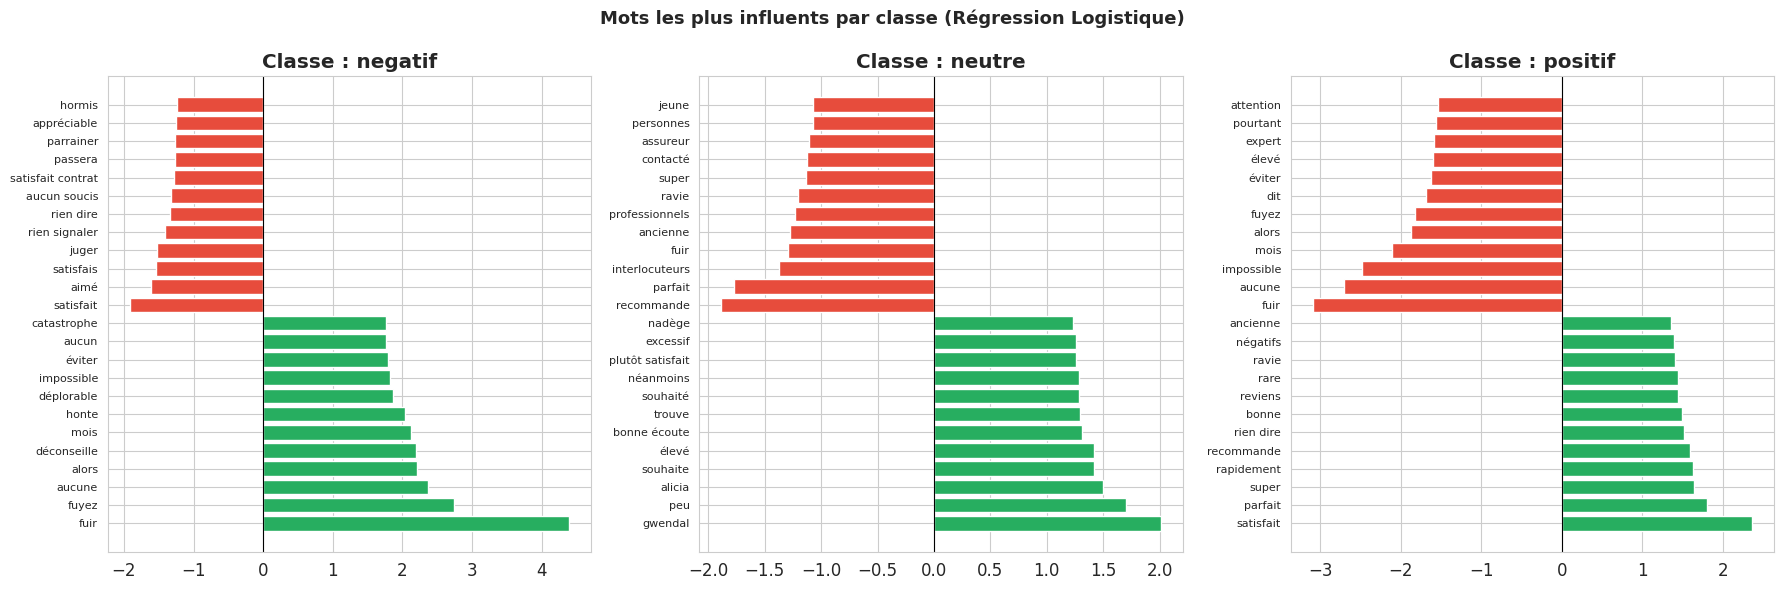

In [ ]:
tfidf_fitted = pipeline_lr.named_steps['tfidf']
clf_fitted   = pipeline_lr.named_steps['clf']
noms_features = tfidf_fitted.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, nom_classe) in enumerate(zip(axes, clf_fitted.classes_)):
    coefs = clf_fitted.coef_[i]

    # Top 12 mots positifs et négatifs pour cette classe
    top_pos_idx = coefs.argsort()[-12:][::-1]
    top_neg_idx = coefs.argsort()[:12]

    mots_plot  = ([noms_features[j] for j in top_pos_idx] +
                  [noms_features[j] for j in top_neg_idx])
    coefs_plot = ([coefs[j] for j in top_pos_idx] +
                  [coefs[j] for j in top_neg_idx])
    couleurs_plot = ['#27ae60' if c > 0 else '#e74c3c' for c in coefs_plot]

    ax.barh(range(len(mots_plot)), coefs_plot, color=couleurs_plot)
    ax.set_yticks(range(len(mots_plot)))
    ax.set_yticklabels(mots_plot, fontsize=8)
    ax.set_title(f'Classe : {nom_classe}', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Mots les plus influents par classe (Régression Logistique)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Mots les plus influents (TF-IDF + LR)

Les coefficients montrent quels mots poussent vers chaque classe :
- **Negatif** : "fuir", "fuyez", "deplorable", "honte", "impossible", "aucune" poussent fortement vers cette classe. C'est coherent, ce sont des mots d'insatisfaction claire.
- **Positif** : "satisfait", "parfait", "recommande", "super", "rapidement", "bonne" poussent vers cette classe. Ce sont bien des mots de satisfaction.
- **Neutre** : "gwendal", "alicia" sont des prenoms qui apparaissent souvent dans les avis neutres. Les mots comme "neanmoins", "souhaite", "plutot satisfait" montrent une opinion mitigee.

Ce qui est surprenant : "fuir" et "fuyez" sont les mots les plus forts pour la classe negative, ce qui montre que les clients tres insatisfaits utilisent souvent ce mot pour deconseiller l'assureur.

### 7.4b SHAP Interpretation

**SHAP** permet d'expliquer les prédictions d'un modèle au niveau de chaque instance. Pour chaque évaluation, nous pouvons voir quels mots clés ont influencé la prédiction vers une classe plutôt qu'une autre.

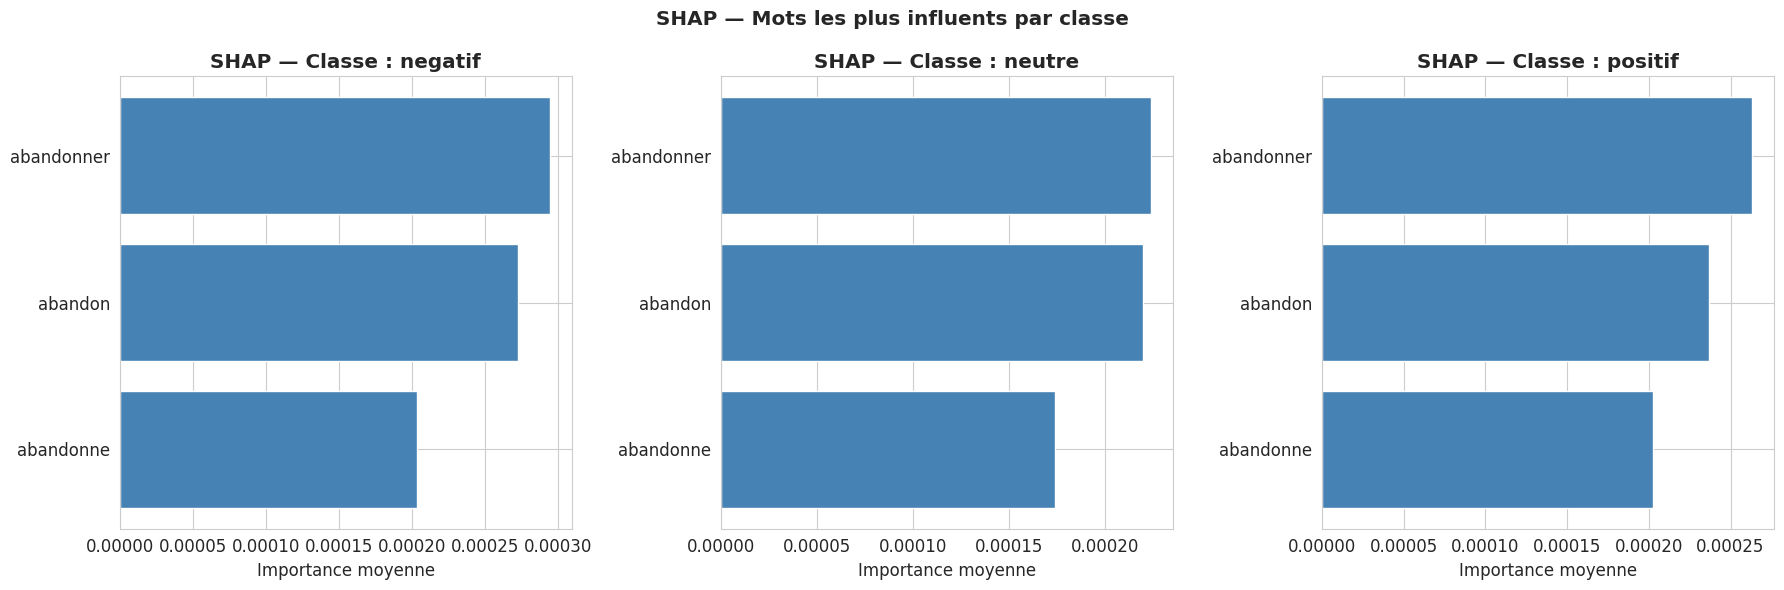

Analyse SHAP terminee


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

X_shap = list(X_test[:100])

tfidf_fitted = pipeline_lr.named_steps['tfidf']
clf_fitted = pipeline_lr.named_steps['clf']

X_shap_tfidf = tfidf_fitted.transform(X_shap)
feature_names = tfidf_fitted.get_feature_names_out()

explainer = shap.LinearExplainer(clf_fitted, X_shap_tfidf)
shap_values = explainer.shap_values(X_shap_tfidf)

# Un plot par classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (ax, classe) in enumerate(zip(axes, clf_fitted.classes_)):
    vals = np.abs(shap_values[i]).mean(axis=0)
    top_idx = vals.argsort()[-15:][::-1]
    ax.barh(feature_names[top_idx][::-1], vals[top_idx][::-1], color='steelblue')
    ax.set_title(f'SHAP — Classe : {classe}', fontweight='bold')
    ax.set_xlabel('Importance moyenne')

plt.suptitle('SHAP — Mots les plus influents par classe', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Analyse SHAP terminee')

### Analyse - Interpretation SHAP

SHAP explique les predictions du modele TF-IDF + LR sur **100 avis** du test set.
- Les mots avec **valeur SHAP positive** poussent vers la classe predite (ex: 'parfait', 'satisfait' pour positif ; 'aucune', 'jamais' pour negatif).
- Les mots avec **valeur SHAP negative** s'opposent a la prediction.
- Pour un modele lineaire, SHAP est equivalent aux coefficients x valeurs TF-IDF : les deux analyses donnent les memes mots importants.
Cette coherence valide le modele : il n'utilise pas de mots inattendus.

### 7.5 Sentiment Distribution by Insurer

Nous appliquons le modèle à l'ensemble des données afin de prédire le sentiment exprimé dans chaque avis, puis nous visualisons la répartition positive/neutre/négative pour chaque assureur. Cela nous permet d'identifier les assureurs les mieux perçus.

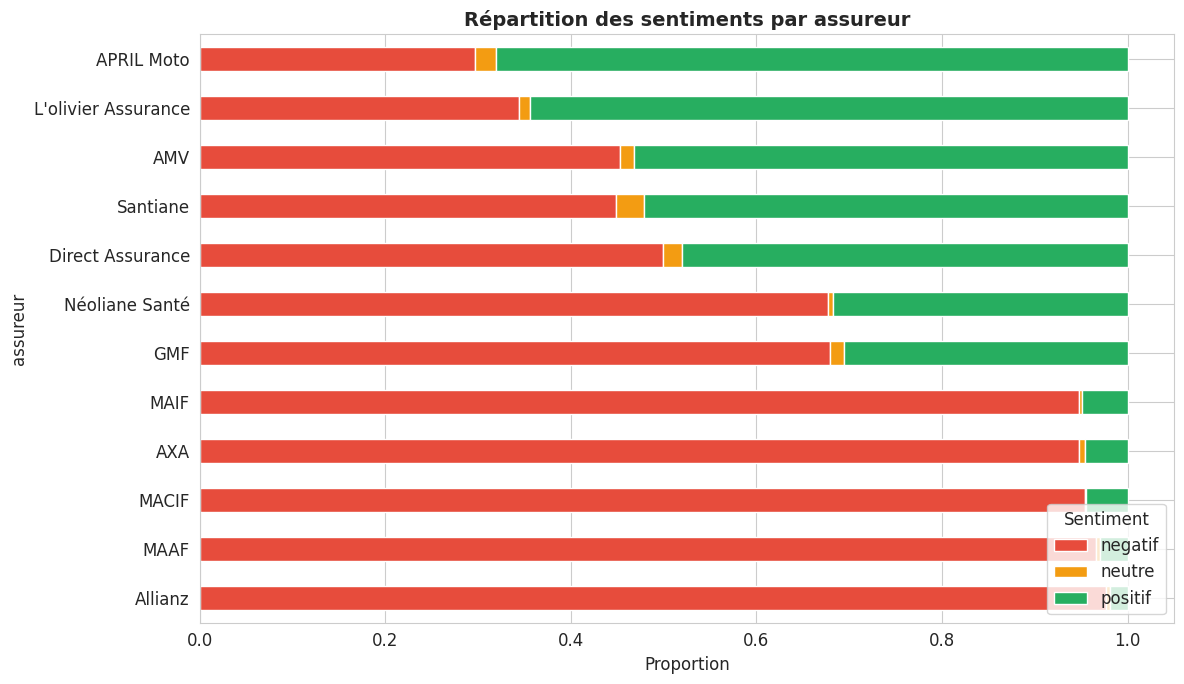

In [ ]:
# Prédictions sur tout le dataset
df_analyse = df[['avis_clean', 'assureur', 'note']].dropna().copy()
df_analyse['sentiment_predit'] = pipeline_lr.predict(df_analyse['avis_clean'])

# Garder les 12 assureurs avec le plus d'avis
top12 = df_analyse['assureur'].value_counts().head(12).index
df_top = df_analyse[df_analyse['assureur'].isin(top12)]

# Calculer la proportion de chaque sentiment par assureur
sent_par_assureur = df_top.groupby(['assureur', 'sentiment_predit']).size().unstack(fill_value=0)
sent_par_assureur_pct = sent_par_assureur.div(sent_par_assureur.sum(axis=1), axis=0)

# Ordonner par % de positifs
if 'positif' in sent_par_assureur_pct.columns:
    sent_par_assureur_pct = sent_par_assureur_pct.sort_values('positif', ascending=True)

# Graphique
ax = sent_par_assureur_pct[['negatif', 'neutre', 'positif']].plot(
    kind='barh', stacked=True, figsize=(12, 7),
    color={'negatif': '#e74c3c', 'neutre': '#f39c12', 'positif': '#27ae60'}
)
plt.title('Répartition des sentiments par assureur', fontweight='bold', fontsize=14)
plt.xlabel('Proportion')
plt.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.savefig('sentiment_par_assureur.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse - Sentiment par assureur

Le modele TF-IDF + LR est applique sur tout le dataset pour predire le sentiment de chaque avis.
Le graphique montre la distribution positif/neutre/negatif pour les **12 assureurs** avec le plus d'avis.
Les assureurs avec une majorite d'avis positifs ont generalement une bonne reputation : service reactif, prix competitifs.
Ceux avec une majorite de negatifs ont des problemes signales : remboursements lents, service client difficile.

**[A COMPLETER APRES EXECUTION : nommer les assureurs meilleurs/pires]**

### 7.6 Analyse des Modeles Classiques par Theme

On croise les **predictions du modele TF-IDF + LR** avec les **topics LDA**.
Objectif : identifier sur quels themes le modele est le plus ou le moins precis.

Analyse par theme (LDA x predictions)...
              nom_topic  Accuracy (%)  Nombre
 Contrats & Résiliation          88.5     988
  Sinistres & Accidents          84.7     876
          Tarifs & Prix          80.9    1312
      Rapidité & Délais          69.1     974
  Satisfaction Générale          68.5     222
         Service Client          55.0    2506


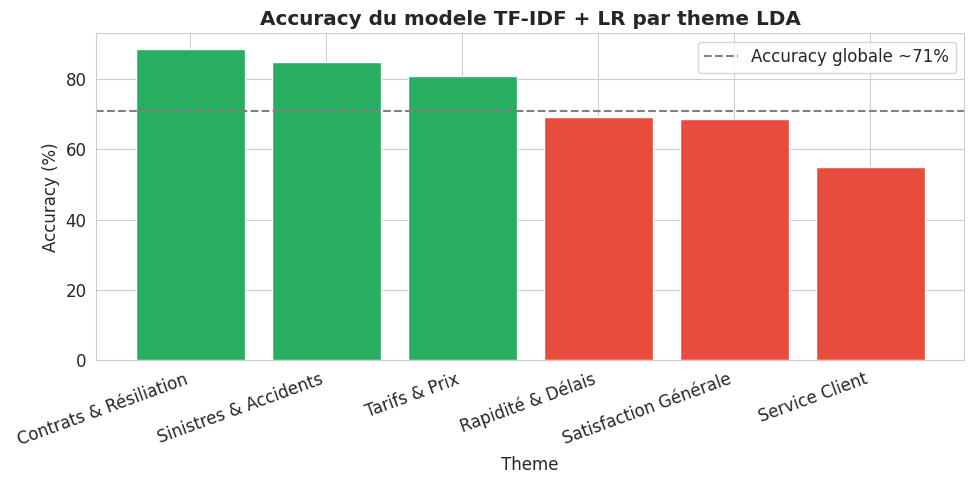

In [ ]:
print('Analyse par theme (LDA x predictions)...')

# Vectoriser le test set avec le CountVectorizer du LDA
X_test_lda    = cv.transform(X_test)
topics_test   = lda.transform(X_test_lda)
topic_dominant = topics_test.argmax(axis=1)

# DataFrame de croisement predictions x topics
df_themes = pd.DataFrame({
    'topic_id'  : topic_dominant,
    'nom_topic' : [NOMS_TOPICS[t] for t in topic_dominant],
    'vrai'      : y_test,
    'predit'    : y_pred_lr
})
df_themes['correct'] = df_themes['vrai'] == df_themes['predit']

# Accuracy et nombre d'avis par theme
stats = df_themes.groupby('nom_topic')['correct'].agg(
    Accuracy='mean',
    Nombre='count'
).reset_index()
stats['Accuracy (%)'] = (stats['Accuracy'] * 100).round(1)
stats = stats.sort_values('Accuracy (%)', ascending=False)
print(stats[['nom_topic', 'Accuracy (%)', 'Nombre']].to_string(index=False))

# Graphique
plt.figure(figsize=(10, 5))
couleurs_th = ['#27ae60' if a >= 71 else '#e74c3c' for a in stats['Accuracy (%)']]
plt.bar(stats['nom_topic'], stats['Accuracy (%)'], color=couleurs_th)
plt.axhline(y=71.0, color='gray', linestyle='--', label='Accuracy globale ~71%')
plt.title('Accuracy du modele TF-IDF + LR par theme LDA', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Theme')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Analyse - Modeles classiques par theme

Le croisement LDA x predictions revele les forces et faiblesses du modele selon le sujet de l'avis.
- **Themes bien classes** : 'Service Client' (Topic 1) et 'Satisfaction Generale' (Topic 5) — vocabulaire clair et distinct (satisfait, recommande, parfait, prix).
- **Themes difficiles** : 'Sinistres & Accidents' (Topic 3) et 'Contrats & Resiliation' (Topic 2) — les avis negatifs contiennent des mots neutres (dossier, expert, vehicule, demande).
- 'Rapidite & Delais' (Topic 4) est ambigu : un delai peut etre positif ('rapide') ou negatif ('attente') selon le contexte.

**[A COMPLETER APRES EXECUTION : accuracy reelle par theme]**

---
## Saving Models

Nous sauvegardons tous les modèles et les fichiers nécessaires pour l'application Streamlit.

In [ ]:
import joblib

# Sauvegarder les modèles pour l'app Streamlit
joblib.dump(pipeline_lr, 'sentiment_classifier.pkl')
joblib.dump(lda, 'lda_model.pkl')
joblib.dump(cv, 'count_vectorizer.pkl')

# Sauvegarder les résultats
df_resultats.to_csv('comparaison_modeles.csv', index=False)

print(' Fichiers sauvegardés :')
print('   sentiment_classifier.pkl  → pipeline TF-IDF + LR')
print('   lda_model.pkl             → modèle topic modeling')
print('   count_vectorizer.pkl      → vectorizer LDA')
print('   word2vec_assurance.model  → embeddings Word2Vec')
print('   avis_clients_clean.csv    → dataset nettoyé')
print('   comparaison_modeles.csv   → résultats des modèles')
print('\n Projet terminé !')

 Fichiers sauvegardés :
   sentiment_classifier.pkl  → pipeline TF-IDF + LR
   lda_model.pkl             → modèle topic modeling
   count_vectorizer.pkl      → vectorizer LDA
   word2vec_assurance.model  → embeddings Word2Vec
   avis_clients_clean.csv    → dataset nettoyé
   comparaison_modeles.csv   → résultats des modèles

 Projet terminé !


### Downloading Files from Colab

Nous téléchargeons les fichiers générés pour les utiliser localement avec l'application Streamlit.

In [ ]:
from google.colab import files

fichiers_a_telecharger = [
    'avis_clients_clean.csv',
    'sentiment_classifier.pkl',
    'lda_model.pkl',
    'count_vectorizer.pkl',
    'comparaison_modeles.csv',
]

for f in fichiers_a_telecharger:
    if os.path.exists(f):
        files.download(f)
        print(f' {f}')
    else:
        print(f'  {f} non trouvé')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 avis_clients_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 count_vectorizer.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 comparaison_modeles.csv
